# Delay-frontier node trees and grouped metric bars

This notebook draws four-tree panels for prices, consumption, climate damages, continuation utility, and node-level marginal utility for the main specification plus robustness specifications. It also draws one four-panel main price bar figure and three six-panel robustness-comparison bar figures. The utility trees require node-level `utility` and `marginal_utility` columns, which are written by the updated cluster runner.

In [1]:
from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data' / 'new_outputs'
FIGURE_DIR = DATA_DIR / 'frontier_tree_metrics' / 'figures'
TREE_FIGURE_DIR = FIGURE_DIR / 'trees'
TABLE_DIR = DATA_DIR / 'frontier_tree_metrics' / 'tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TREE_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

N_TREE_PERIODS = 6  # 2025 through 2100
METRICS = {
    'price': {'column': 'price', 'label': 'Price ($)', 'formatter': lambda value: f'${value:,.0f}'},
    'consumption': {'column': 'consumption', 'label': 'Consumption', 'formatter': lambda value: f'{value:,.3f}'},
    'damage': {'column': 'climate_damage', 'label': 'Climate damages (%)', 'formatter': lambda value: f'{100 * value:.2f}%'},
    'utility': {'column': 'utility', 'label': 'Continuation utility', 'formatter': lambda value: f'{value:,.3f}'},
    'marginal_utility': {'column': 'marginal_utility', 'label': r'Marginal utility ($\partial V/\partial C$)', 'formatter': lambda value: f'{value:.3g}'},
}
TREE_METRIC_KEYS = ('price', 'consumption', 'damage', 'utility', 'marginal_utility')
BAR_METRIC_KEYS = ('price', 'consumption', 'damage')

RUNS = {
    'main': {
        'folder': 'paper-august-main-frontier-v2',
        'tree_panels': [
            ('Unconstrained optimum', 'prefs_ra7_eis0p9_prtp0p005', 5, 'optimal'),
            ('5-year delay', 'prefs_ra7_eis0p9_prtp0p005', 5, 'delayed'),
            ('10-year delay', 'prefs_ra7_eis0p9_prtp0p005', 10, 'delayed'),
            ('15-year delay', 'prefs_ra7_eis0p9_prtp0p005', 15, 'delayed'),
        ],
    },
    'robustness': {
        'folder': 'paper-august-robustness-frontier-v2',
        'specs': [
            ('Low EIS (=0.55)', 'low_eis'),
            ('High RA (=15)', 'high_ra'),
            ('Low RA (=3)', 'low_ra'),
            ('No endogenous learning (tech. scale = 0)', 'no_endogenous_learning'),
        ],
    },
}
MAIN_TREE_PANELS = [
    ('Unconstrained optimum', 'prefs_ra7_eis0p9_prtp0p005', 5, 'optimal'),
    ('5-year delay', 'prefs_ra7_eis0p9_prtp0p005', 5, 'delayed'),
    ('10-year delay', 'prefs_ra7_eis0p9_prtp0p005', 10, 'delayed'),
    ('15-year delay', 'prefs_ra7_eis0p9_prtp0p005', 15, 'delayed'),
]
MAIN_BAR_PANELS = [
    ('Unconstrained optimum', 'prefs_ra7_eis0p9_prtp0p005', 5, 'optimal'),
    ('5-year delay', 'prefs_ra7_eis0p9_prtp0p005', 5, 'delayed'),
    ('10-year delay', 'prefs_ra7_eis0p9_prtp0p005', 10, 'delayed'),
    ('15-year delay', 'prefs_ra7_eis0p9_prtp0p005', 15, 'delayed'),
]
ROBUSTNESS_TREE_PANELS = [
    ('Unconstrained optimum', None, 5, 'optimal'),
    ('5-year delay', None, 5, 'delayed'),
    ('10-year delay', None, 10, 'delayed'),
    ('15-year delay', None, 15, 'delayed'),
]
BAR_ROBUSTNESS_SPECS = [
    ('Low EIS (=0.55)', 'low_eis'),
    ('High RA (=15)', 'high_ra'),
    ('Low RA (=3)', 'low_ra'),
    ('No endogenous learning (tech. scale = 0)', 'no_endogenous_learning'),
]

# This is the existing CAP6 spaced-tree parent relation: the middle states partly recombine.
SPACED_TREE_PARENT_OFFSETS = (
    (1, 2, 1, 2),
    (1, 2, 3, 1, 2, 3, 4, 5, 6, 4, 5, 6),
    (1, 2, 3, 4, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 11, 12, 13, 14),
)


def parent_states(period):
    n_children, n_parents = 2 ** period, 2 ** (period - 1)
    states = []
    for child in range(n_children):
        if child < 2:
            parent = 0
        elif child >= n_children - 2:
            parent = n_parents - 1
        elif period - 3 < len(SPACED_TREE_PARENT_OFFSETS):
            parent = SPACED_TREE_PARENT_OFFSETS[period - 3][child - 2]
        else:
            parent = (child - 2) // 2
        states.append(parent)
    return np.asarray(states, dtype=int)


def centered_tree_layout(final_period, top=0.96, bottom=0.04):
    y_by_period = {final_period: np.linspace(top, bottom, 2 ** final_period)}
    parents_by_period = {}
    for period in range(final_period, 0, -1):
        parents = parent_states(period)
        parents_by_period[period] = parents
        y_by_period[period - 1] = np.array([
            y_by_period[period][parents == parent].mean()
            for parent in range(2 ** (period - 1))
        ])
    return y_by_period, parents_by_period


# Match the appendix renderer in paper_facing_plots.ipynb exactly.
TREE_X_BY_PERIOD = np.array([0.035, 0.205, 0.375, 0.545, 0.715, 0.905])
TREE_BOX_STYLE = {
    0: (0.120, 0.060, plt.rcParams['font.size'] * 1.90),
    1: (0.112, 0.052, plt.rcParams['font.size'] * 1.77),
    2: (0.140, 0.038, plt.rcParams['font.size'] * 1.55),
    3: (0.130, 0.032, plt.rcParams['font.size'] * 1.35),
    4: (0.120, 0.028, plt.rcParams['font.size'] * 1.20),
    5: (0.095, 0.026, plt.rcParams['font.size'] * 0.95),
}
TREE_FACE = {'optimal': '#daffd9', 'delayed': '#dfdfdf'}


def node_file(folder):
    return DATA_DIR / folder / 'analysis' / f'{folder}_node_prices.csv'


def read_nodes(run_key):
    path = node_file(RUNS[run_key]['folder'])
    frame = pd.read_csv(path)
    required = {'sample_index', 'delay_year', 'scenario', 'node', 'period', 'calendar_year', 'price', 'consumption', 'climate_damage', 'utility', 'marginal_utility'}
    missing = required.difference(frame.columns)
    if missing:
        raise RuntimeError(
            f'{path} lacks {sorted(missing)}. Rerun {RUNS[run_key]["folder"]} with the updated main_ensemble_delayed_cluster.py to write node consumption, climate damage, continuation utility, and marginal utility.'
        )
    numeric = ['delay_year', 'node', 'period', 'calendar_year', 'price', 'consumption', 'climate_damage', 'utility', 'marginal_utility']
    frame[numeric] = frame[numeric].apply(pd.to_numeric, errors='coerce')
    return frame


def select_nodes(frame, sample_index, delay_year, scenario):
    subset = frame.loc[
        (frame['sample_index'] == sample_index)
        & (frame['delay_year'] == delay_year)
        & (frame['scenario'] == scenario)
        & (frame['period'] < N_TREE_PERIODS)
    ].copy().sort_values('node')
    expected = 2 ** N_TREE_PERIODS - 1
    if len(subset) != expected:
        raise ValueError(f'Expected {expected} nodes, found {len(subset)} for {sample_index}, delay={delay_year}, scenario={scenario}.')
    return subset


def draw_tree(ax, nodes, metric_key, title, scenario):
    metric = METRICS[metric_key]
    y_by_period, parents_by_period = centered_tree_layout(N_TREE_PERIODS - 1, top=0.99, bottom=0.01)
    nodes = nodes.sort_values('node')
    value_by_node = nodes.set_index('node')[metric['column']].astype(float).to_dict()
    coords = {}
    for period, group in nodes.groupby('period'):
        period = int(period)
        group = group.sort_values('node')
        if len(group) != len(y_by_period[period]):
            raise ValueError(f'Unexpected node count in period {period}.')
        for state, (_, row) in enumerate(group.iterrows()):
            coords[int(row['node'])] = (TREE_X_BY_PERIOD[period], y_by_period[period][state], period, state)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_facecolor('white')
    ax.set_yticks([])
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    for child, (x1, y1, period, state) in coords.items():
        if period == 0:
            continue
        parent_state = parents_by_period[period][state]
        parent = 2 ** (period - 1) - 1 + parent_state
        x0, y0, parent_period, _ = coords[parent]
        parent_width = TREE_BOX_STYLE[parent_period][0]
        child_width = TREE_BOX_STYLE[period][0]
        ax.plot([x0 + parent_width / 2, x1 - child_width / 2], [y0, y1], transform=ax.transAxes, color='0.12', lw=0.42, zorder=1, clip_on=False)
    for node, (x, y, period, _) in coords.items():
        width, height, fontsize = TREE_BOX_STYLE[period]
        rect = Rectangle((x - width / 2, y - height / 2), width, height, transform=ax.transAxes, facecolor=TREE_FACE[scenario], edgecolor='0.15', lw=0.8, zorder=2, clip_on=False)
        ax.add_patch(rect)
        label = metric['formatter'](value_by_node[node])
        text = ax.text(x, y, label, transform=ax.transAxes, ha='center', va='center_baseline', fontsize=fontsize, fontfamily='Helvetica', fontweight='bold', zorder=3, clip_on=False)
        ax.figure.canvas.draw()
        renderer = ax.figure.canvas.get_renderer()
        box_extent = rect.get_window_extent(renderer)
        text_extent = text.get_window_extent(renderer)
        fit_scale = min(1.0, 0.90 * box_extent.width / max(text_extent.width, 1.0), 0.82 * box_extent.height / max(text_extent.height, 1.0))
        if fit_scale < 1.0:
            text.set_fontsize(fontsize * fit_scale)
    years = nodes.groupby('period')['calendar_year'].first().sort_index().astype(int).to_numpy()
    tick_y = -0.030
    for x, year in zip(TREE_X_BY_PERIOD, years):
        ax.plot([x, x], [-0.006, -0.017], transform=ax.transAxes, color='0.15', lw=0.6, clip_on=False)
        ax.text(x, tick_y, str(year), transform=ax.transAxes, ha='center', va='top', fontsize=plt.rcParams['axes.titlesize'], fontfamily='Helvetica', clip_on=False)
    ax.plot([TREE_X_BY_PERIOD[0], TREE_X_BY_PERIOD[-1]], [-0.006, -0.006], transform=ax.transAxes, color='0.15', lw=0.7, clip_on=False)
    ax.set_title(title, fontsize=plt.rcParams['axes.titlesize'], fontweight='bold', fontfamily='Helvetica', pad=2)


def save_tree_panel(node_data, metric_key, run_key, title, sample, panels):
    fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.5), constrained_layout=False)
    for ax, (panel_title, panel_sample, delay, scenario) in zip(axes.flat, panels):
        panel_sample = sample if panel_sample is None else panel_sample
        draw_tree(ax, select_nodes(node_data[run_key], panel_sample, delay, scenario), metric_key, panel_title, scenario)
    fig.suptitle(title, fontsize=plt.rcParams['axes.titlesize'], fontweight='bold', fontfamily='Helvetica', y=0.92)
    fig.supxlabel('Year', fontsize=plt.rcParams['axes.titlesize'], fontweight='bold', fontfamily='Helvetica', y=0.035)
    fig.supylabel(METRICS[metric_key]['label'], fontsize=plt.rcParams['axes.titlesize'], fontweight='bold', fontfamily='Helvetica',
                  x=0.1)
    # Keep tree PDFs separate from the bar figures: trees/<metric>/<run>/<specification>.pdf.
    output_dir = TREE_FIGURE_DIR / metric_key / run_key
    output_dir.mkdir(parents=True, exist_ok=True)
    slug = re.sub(r'[^a-z0-9]+', '_', title.lower()).strip('_')
    filename = f'{slug}_trees.pdf'
    fig.savefig(output_dir / filename, bbox_inches='tight')
    display(fig)
    plt.close(fig)


def save_tree_figures(node_data):
    for metric_key in TREE_METRIC_KEYS:
        save_tree_panel(node_data, metric_key, 'main', 'Main specification (RA=7, EIS=0.90, PRTP=0.005)', 'prefs_ra7_eis0p9_prtp0p005', MAIN_TREE_PANELS)
        for title, sample in RUNS['robustness']['specs']:
            save_tree_panel(node_data, metric_key, 'robustness', title, sample, ROBUSTNESS_TREE_PANELS)

colors = ["#00A1FD", "#037EC6", "#035787", "#0420DA", "#A704C4", "#7206F7"]

def draw_grouped_bars(ax, nodes, metric_key, title, scenario):
    metric = METRICS[metric_key]
    nodes = nodes.sort_values(['period', 'node'])
    years = sorted(nodes['calendar_year'].unique())
    for x, year in enumerate(years):
        values = nodes.loc[nodes['calendar_year'] == year, metric['column']].to_numpy(dtype=float)
        width = 0.76 / len(values)
        offsets = (np.arange(len(values)) - (len(values) - 1) / 2) * width
        ax.bar(x + offsets, values, width=width * 0.94, color=colors[x % len(colors)], edgecolor='white', lw=0.6, zorder=2)
    ax.set_xticks(range(len(years)), labels=years, rotation=0)
    ax.set_xlabel('Year')
    ax.set_ylabel(METRICS[metric_key]['label'])
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', color='0.9', lw=0.6)
    ax.set_axisbelow(True)


def save_main_price_bar_figure(node_data):
    # One four-panel price figure for the main specification: optimum plus three delays.
    fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.5), constrained_layout=True)
    for ax, (title, sample, delay, scenario) in zip(axes.flat, MAIN_BAR_PANELS):
        draw_grouped_bars(ax, select_nodes(node_data['main'], sample, delay, scenario), 'price', title, scenario)
    fig.savefig(FIGURE_DIR / 'main_price_node_bars_unconstrained_and_delays.pdf', bbox_inches='tight')
    display(fig)
    plt.close(fig)


def save_unconstrained_comparison_bar_figures(node_data):
    # Three six-panel figures: unconstrained main plus the five robustness specifications.
    for metric_key in BAR_METRIC_KEYS:
        fig, axes = plt.subplots(2, 3, figsize=(15.0, 9.0), constrained_layout=True)
        main_nodes = select_nodes(node_data['main'], 'prefs_ra7_eis0p9_prtp0p005', 5, 'optimal')
        draw_grouped_bars(axes.flat[0], main_nodes, metric_key, 'Unconstrained main', 'optimal')
        for ax, (title, sample) in zip(axes.flat[1:], BAR_ROBUSTNESS_SPECS):
            nodes = select_nodes(node_data['robustness'], sample, 10, 'optimal')
            draw_grouped_bars(ax, nodes, metric_key, title, 'optimal')
        fig.savefig(FIGURE_DIR / f'{metric_key}_node_bars_main_and_robustness.pdf', bbox_inches='tight')
        display(fig)
        plt.close(fig)


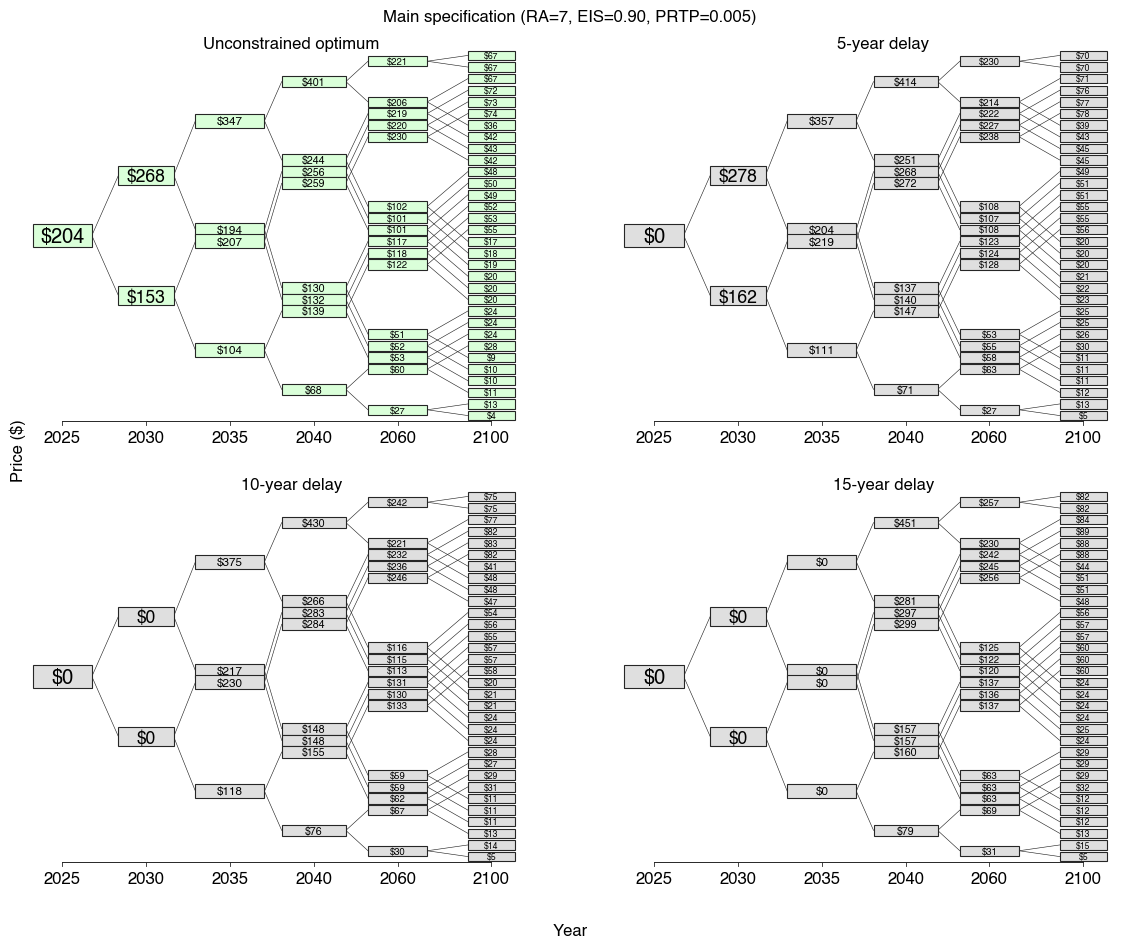

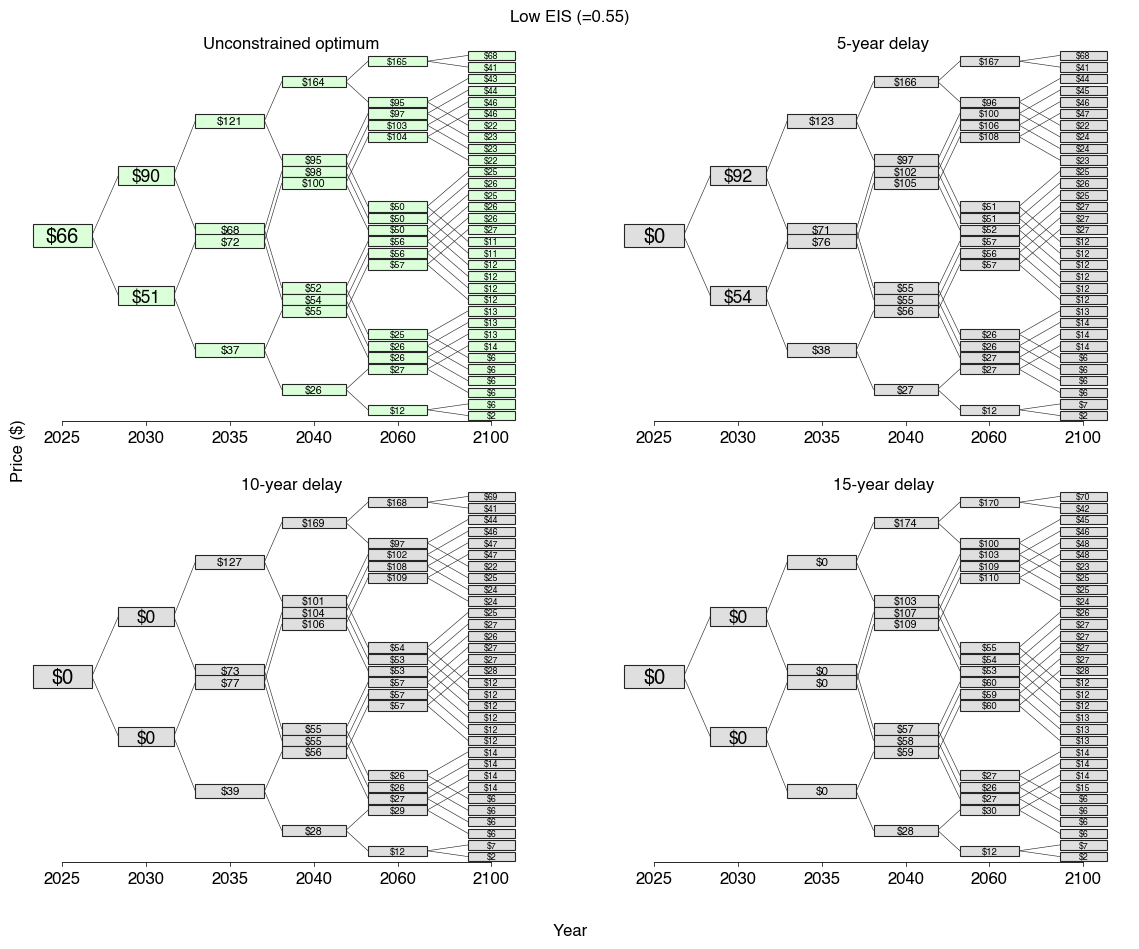

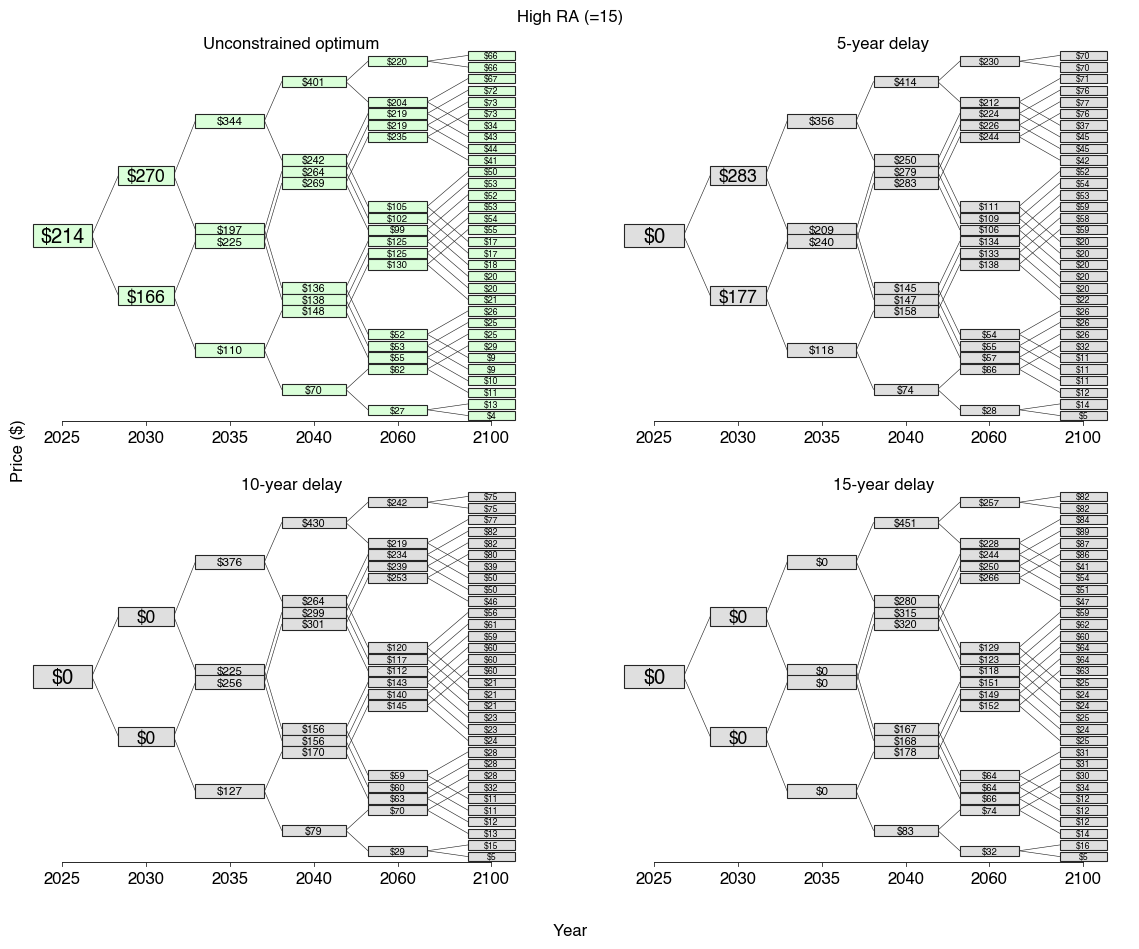

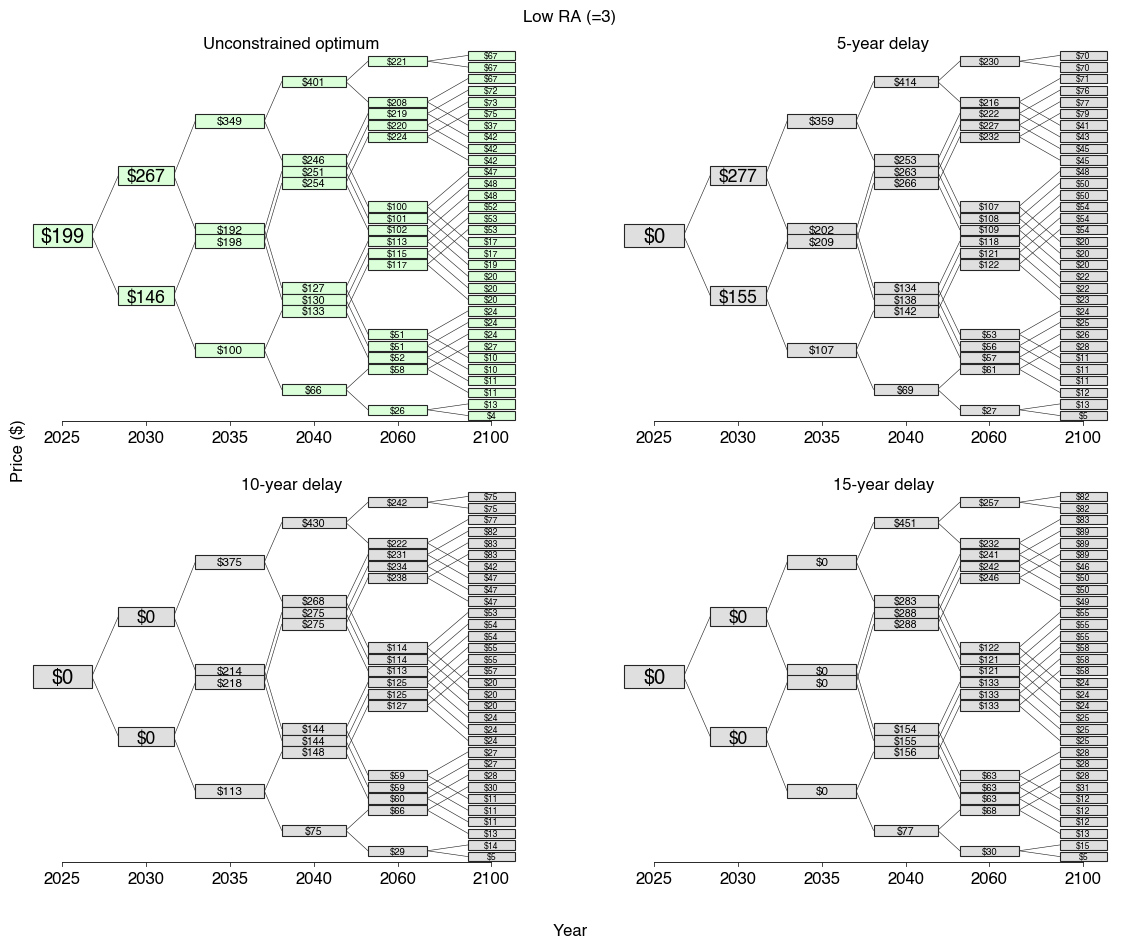

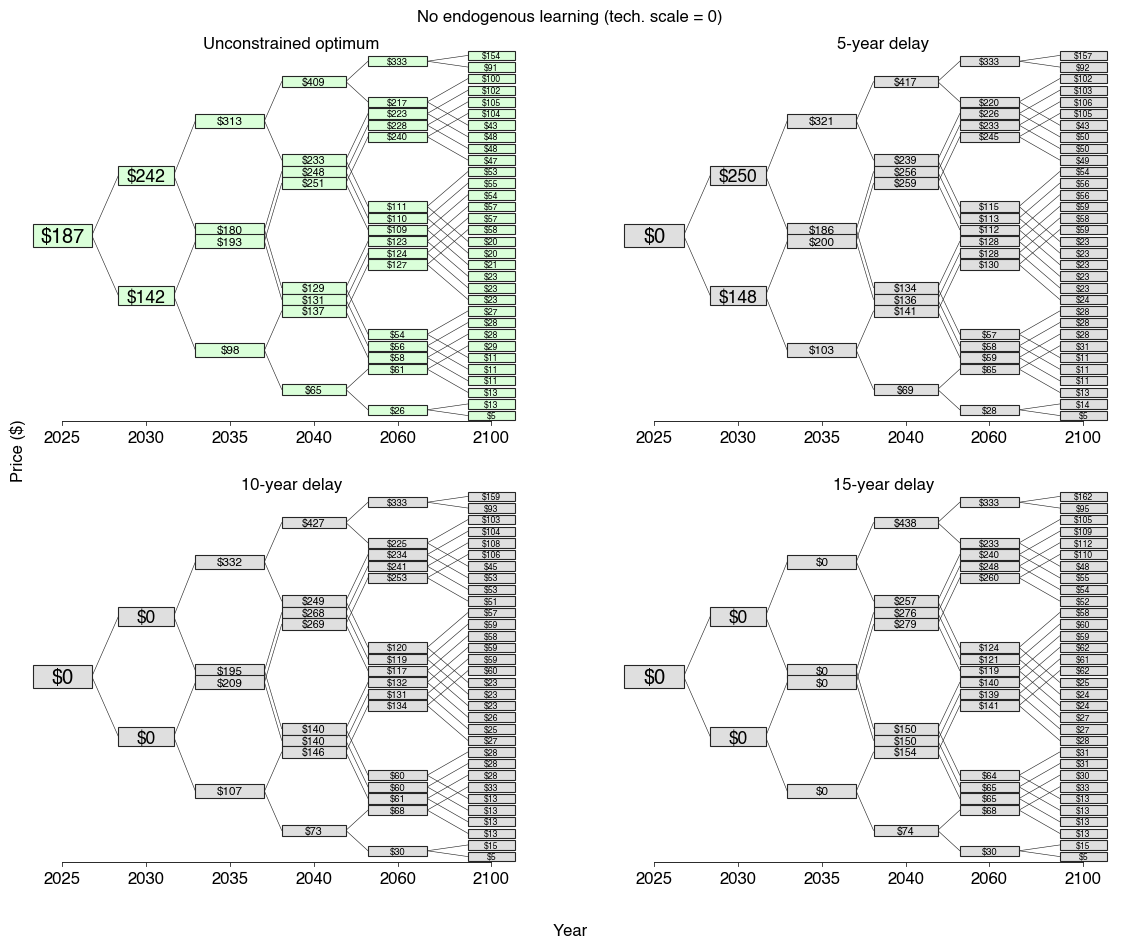

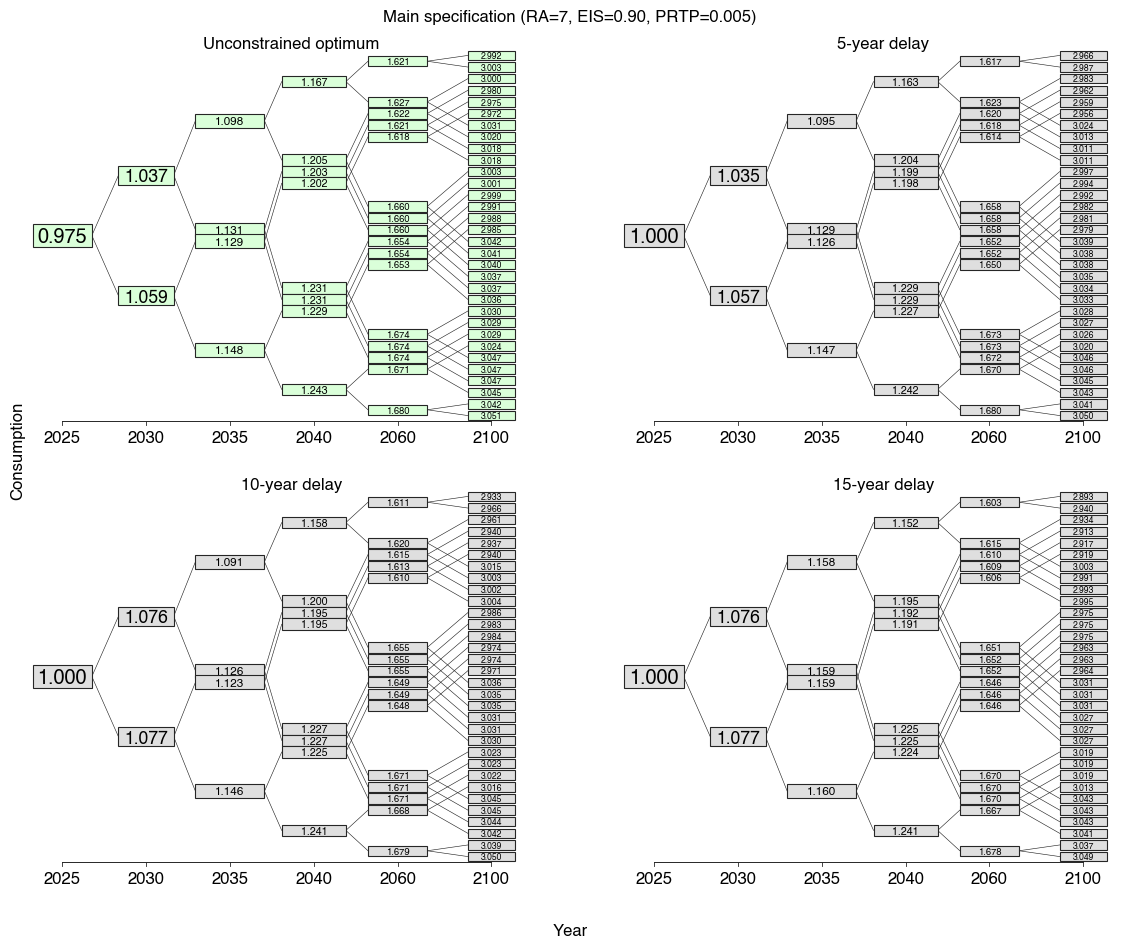

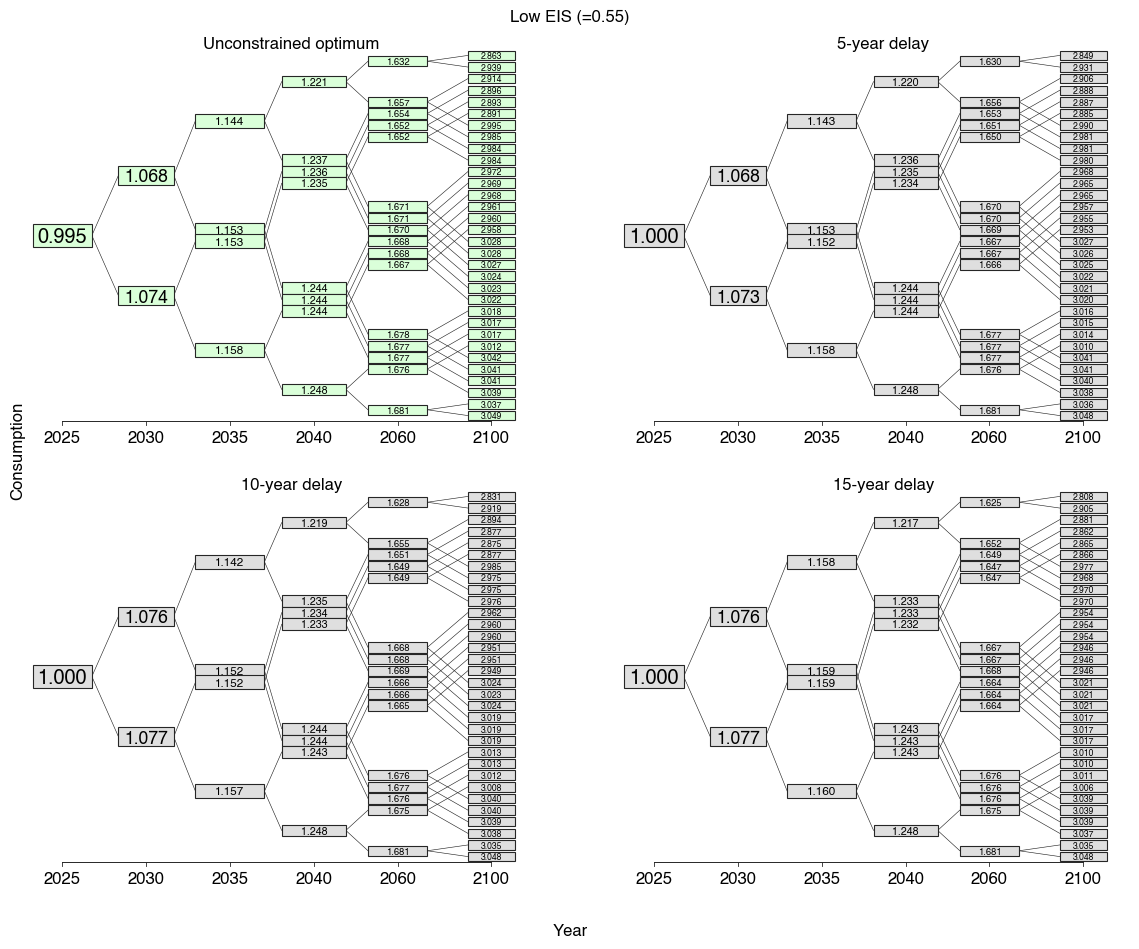

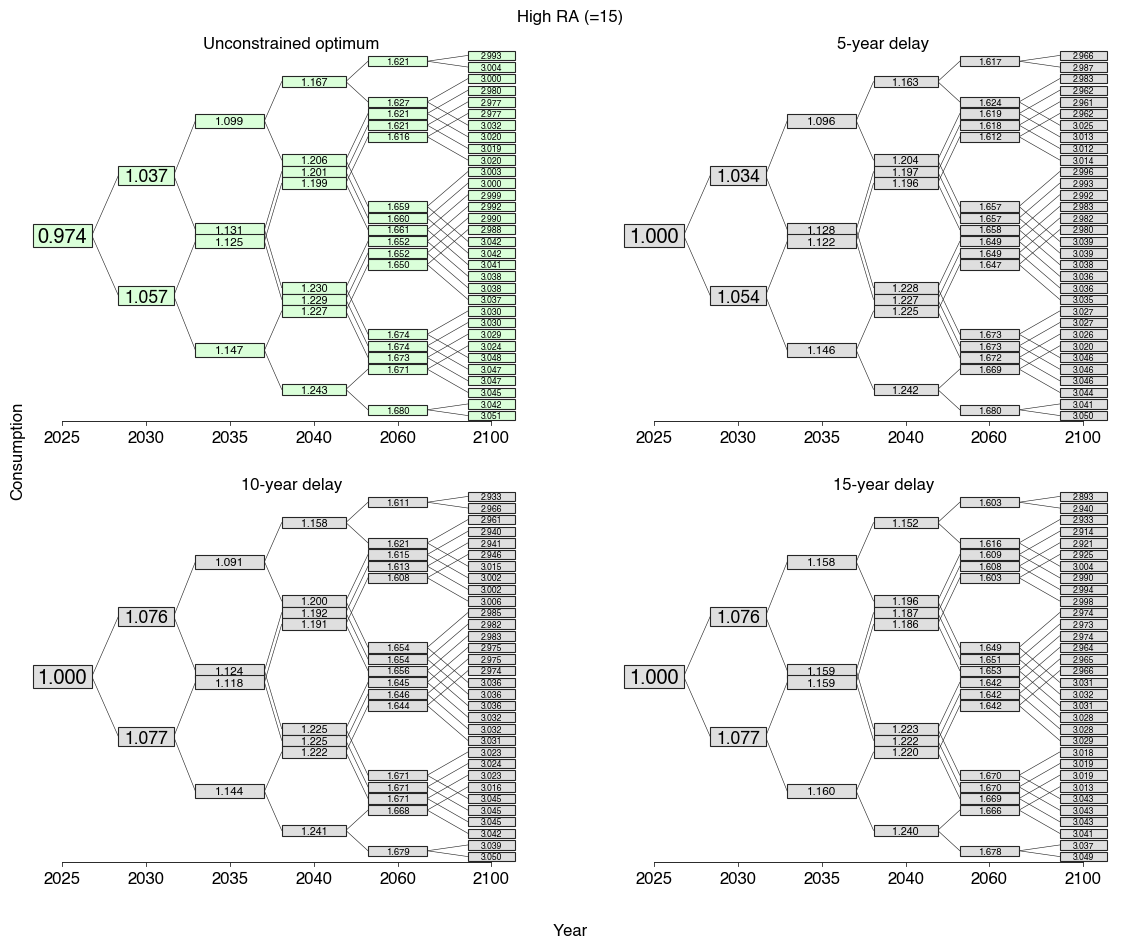

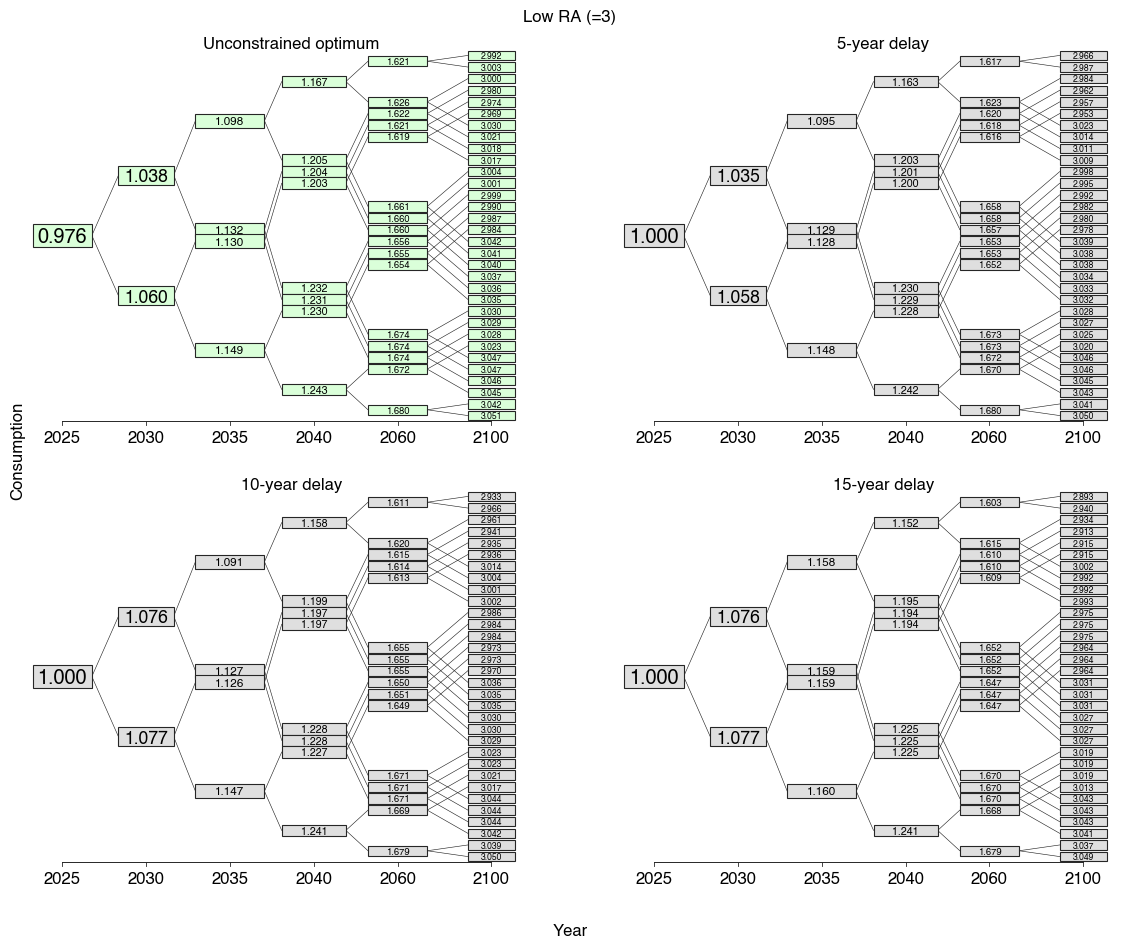

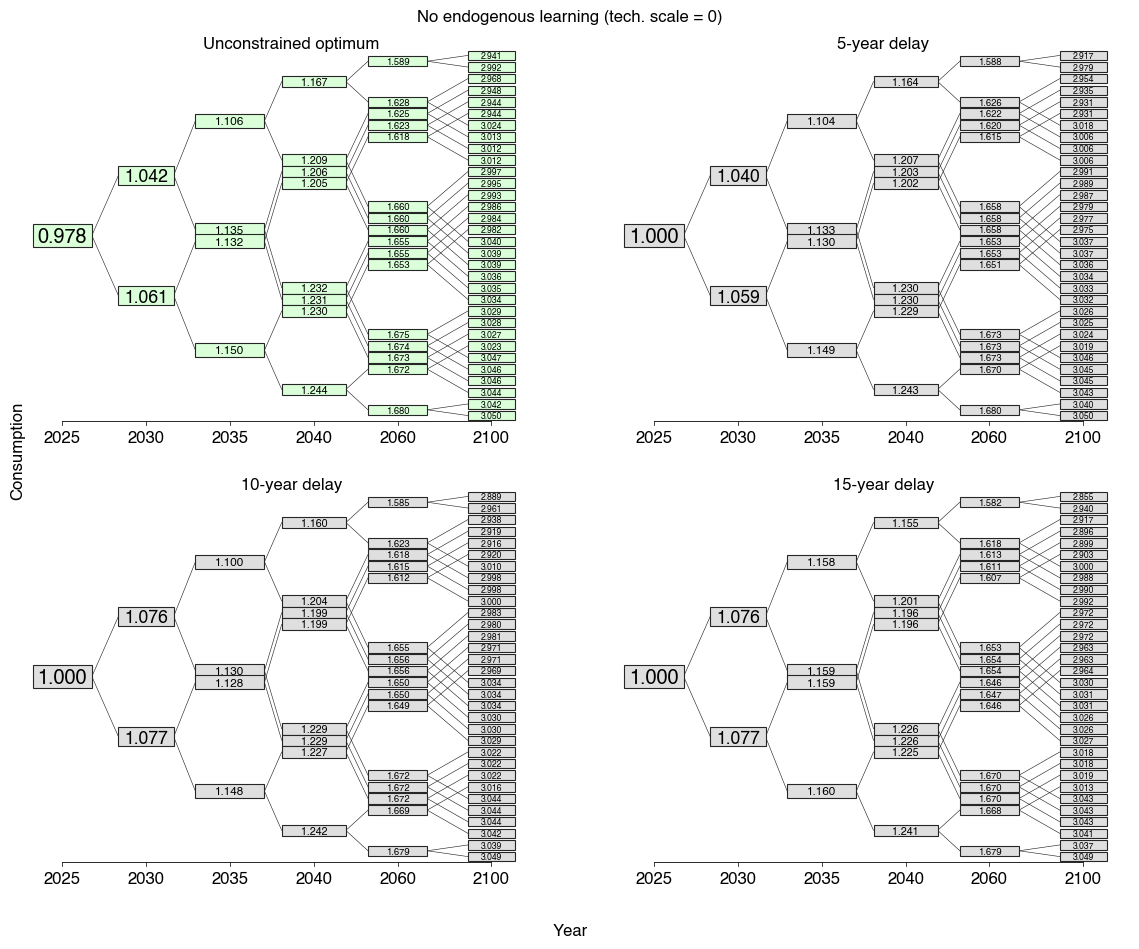

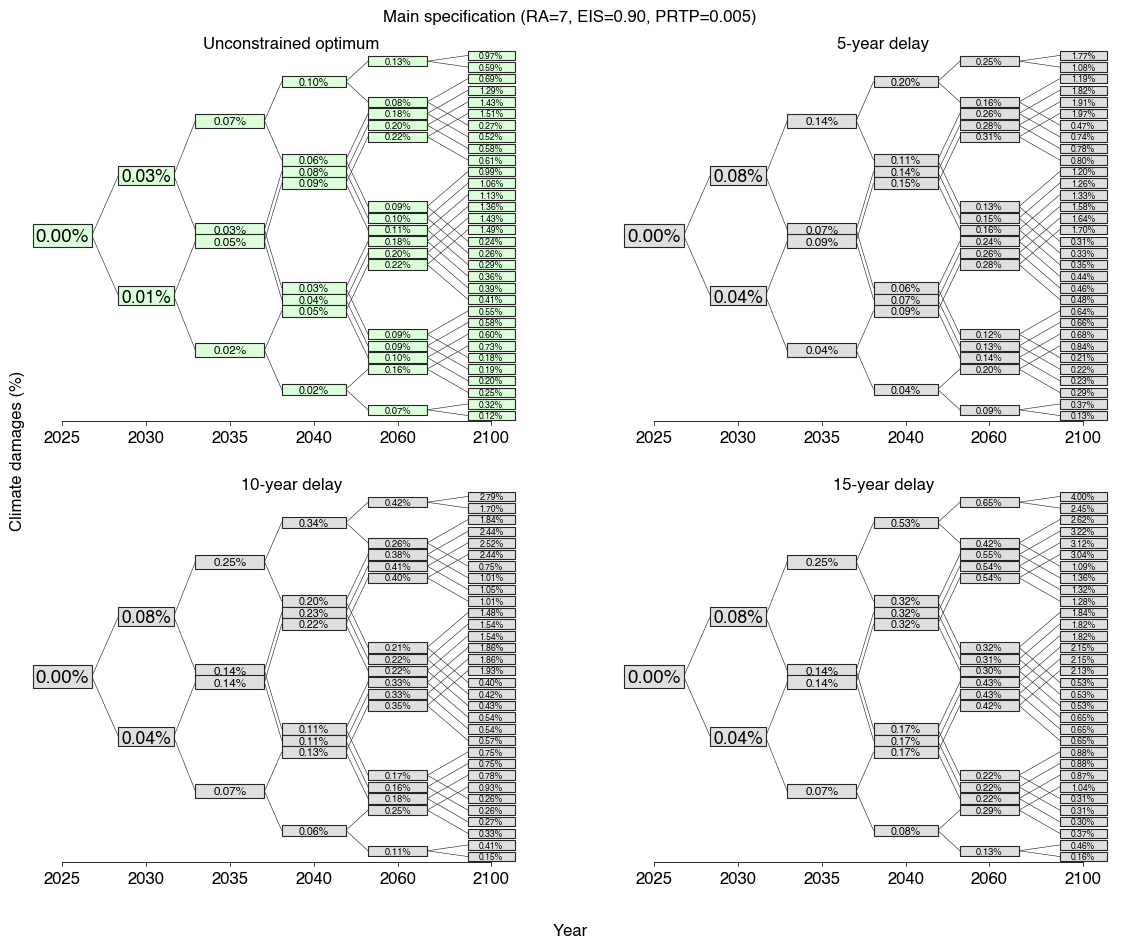

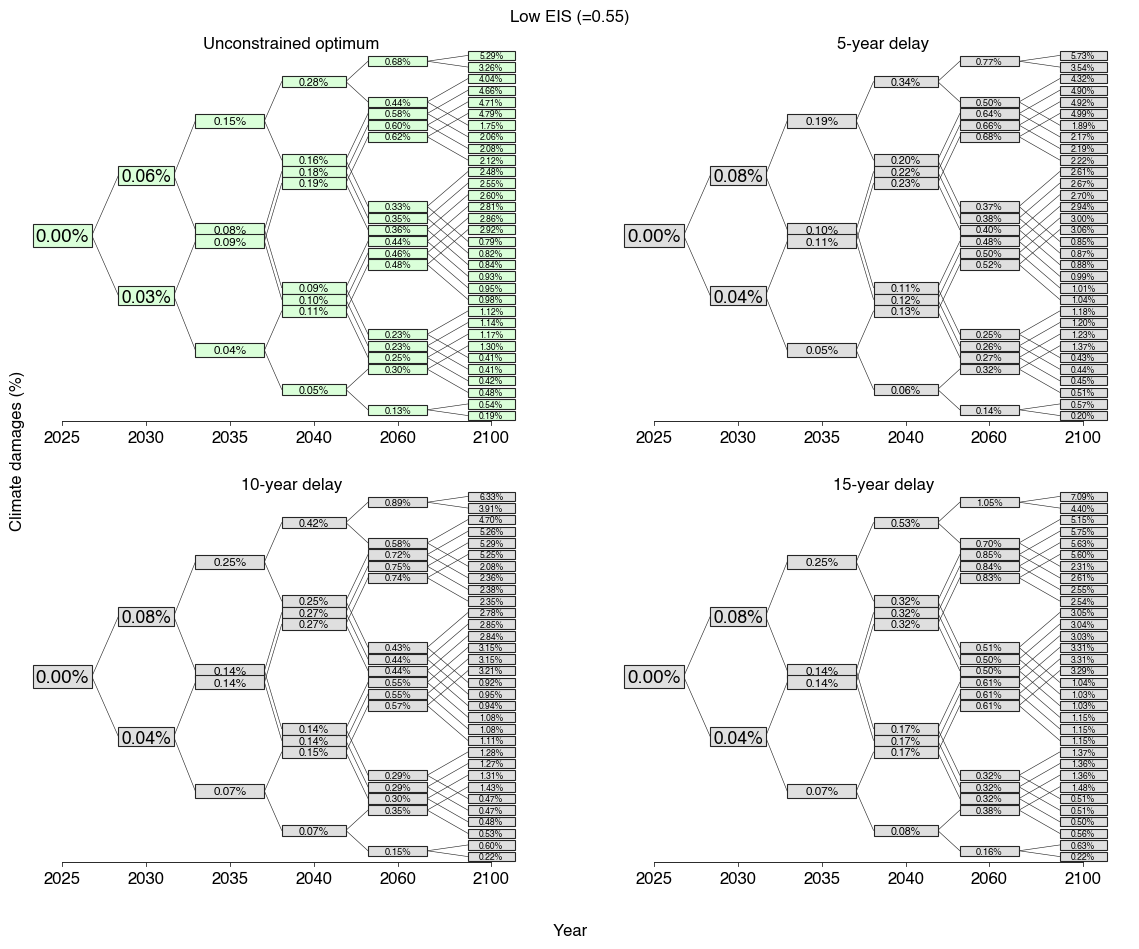

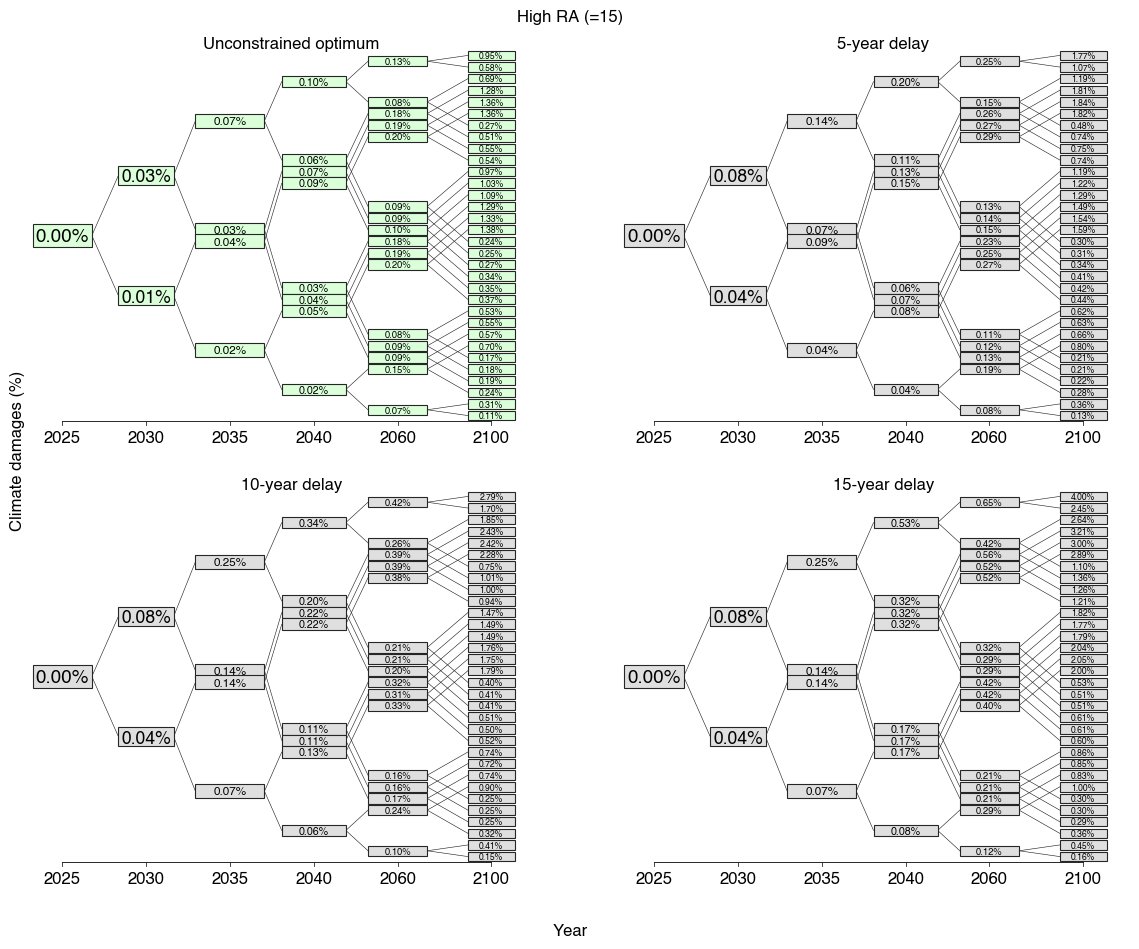

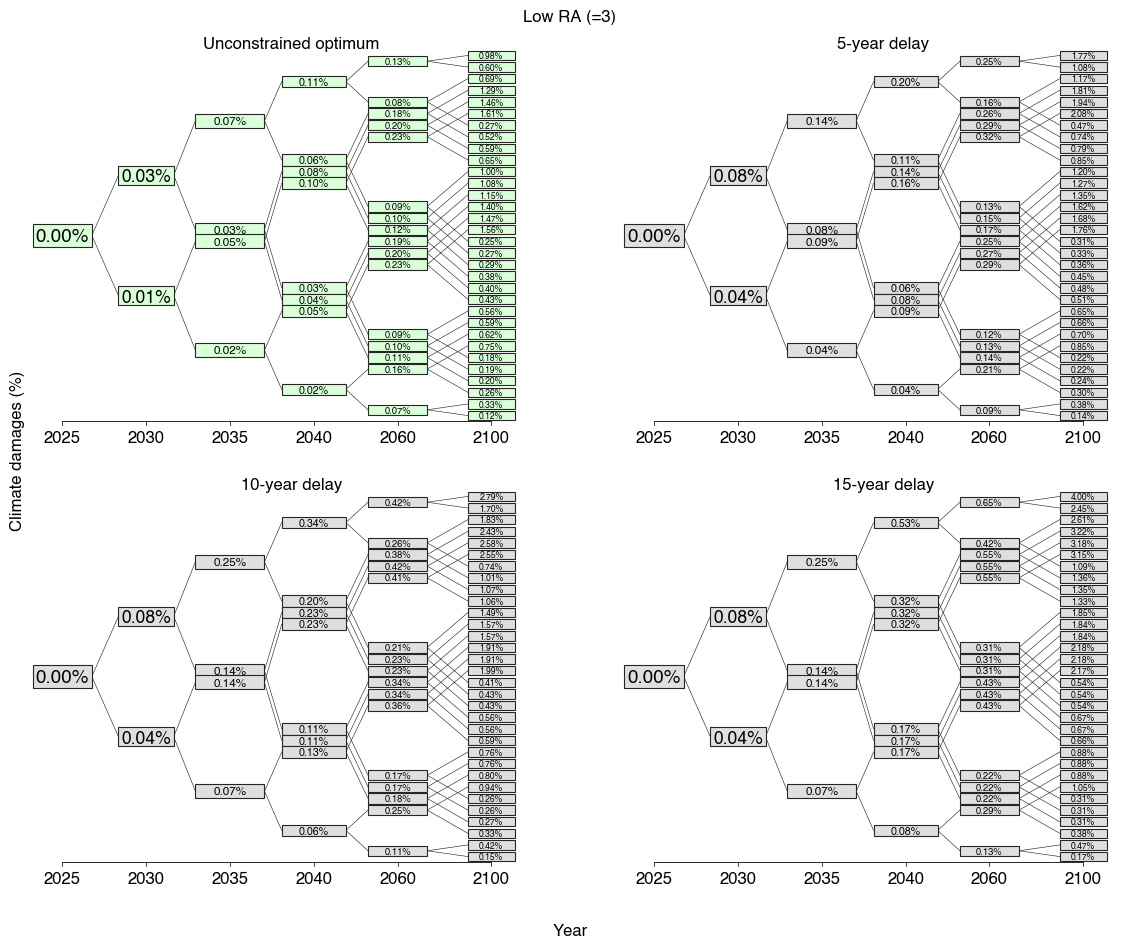

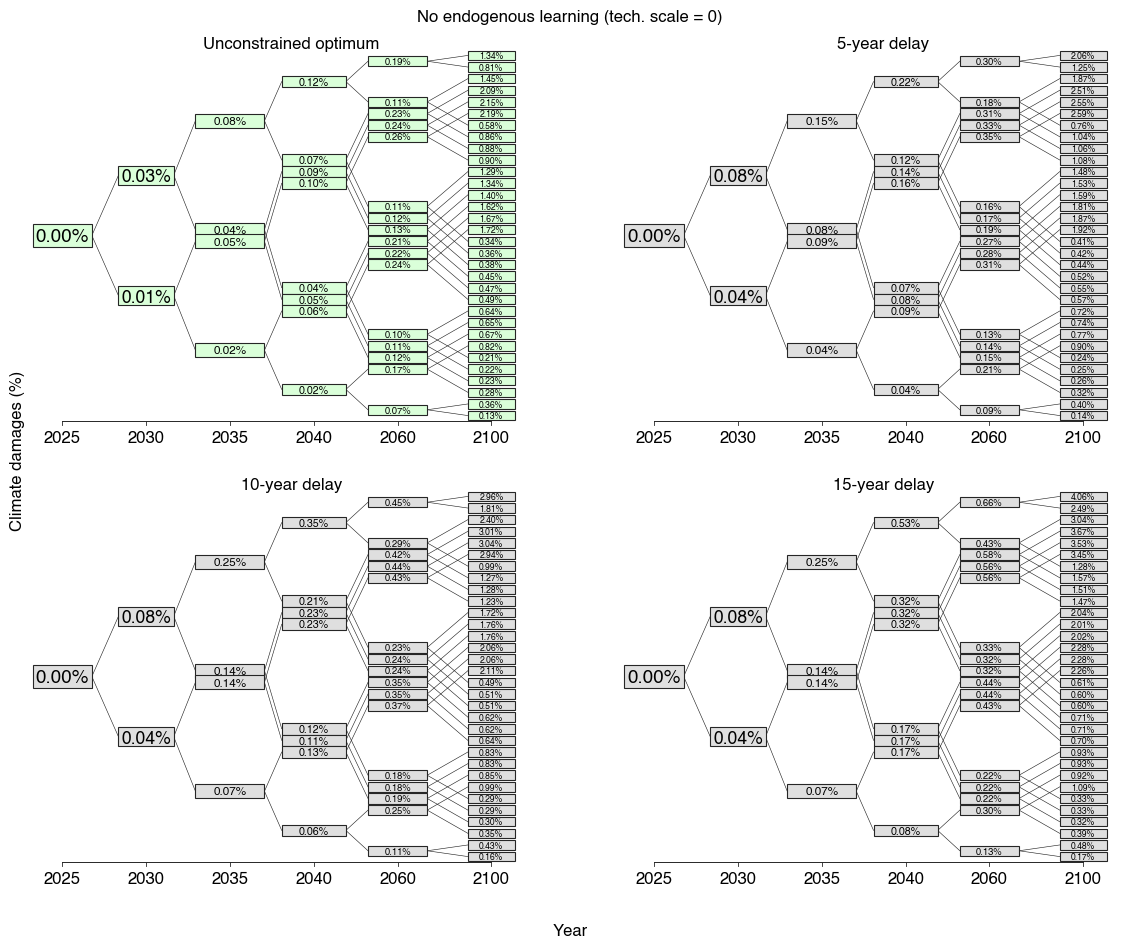

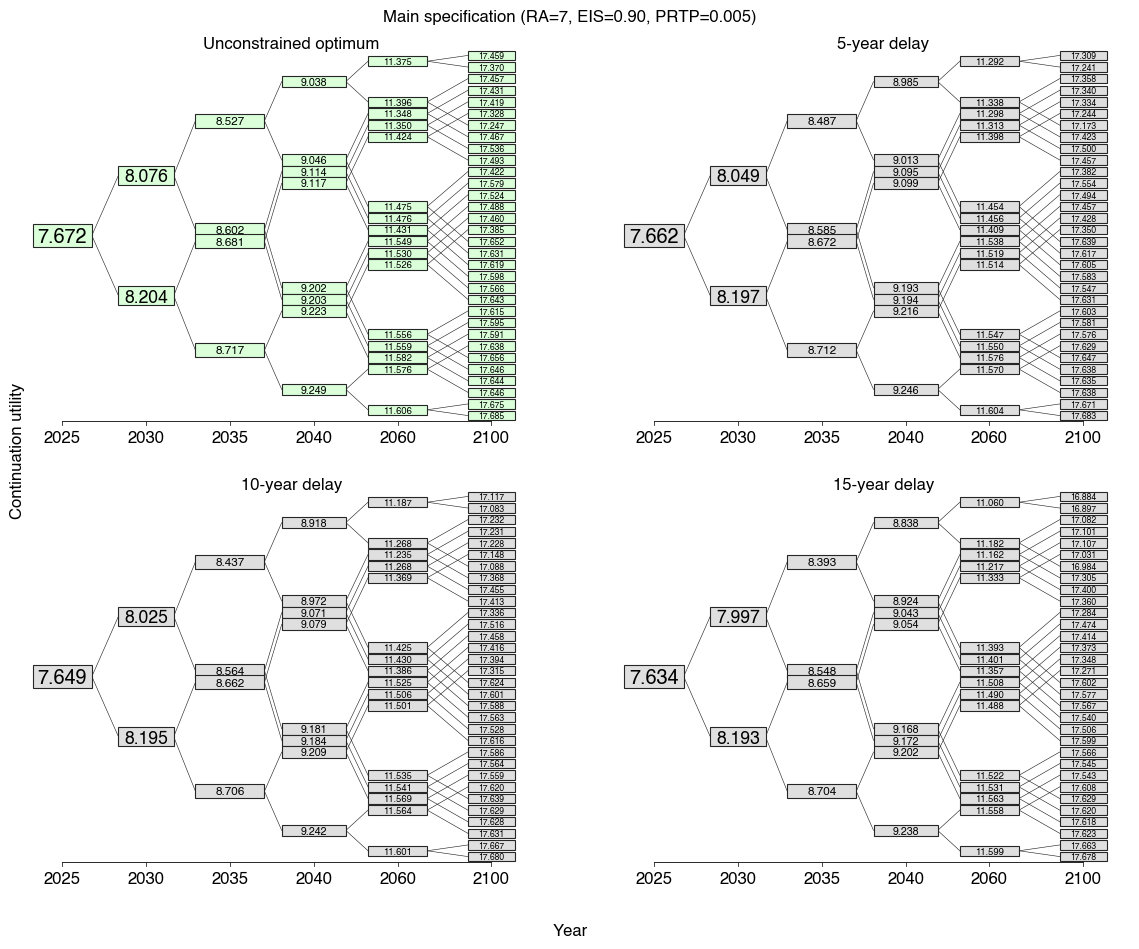

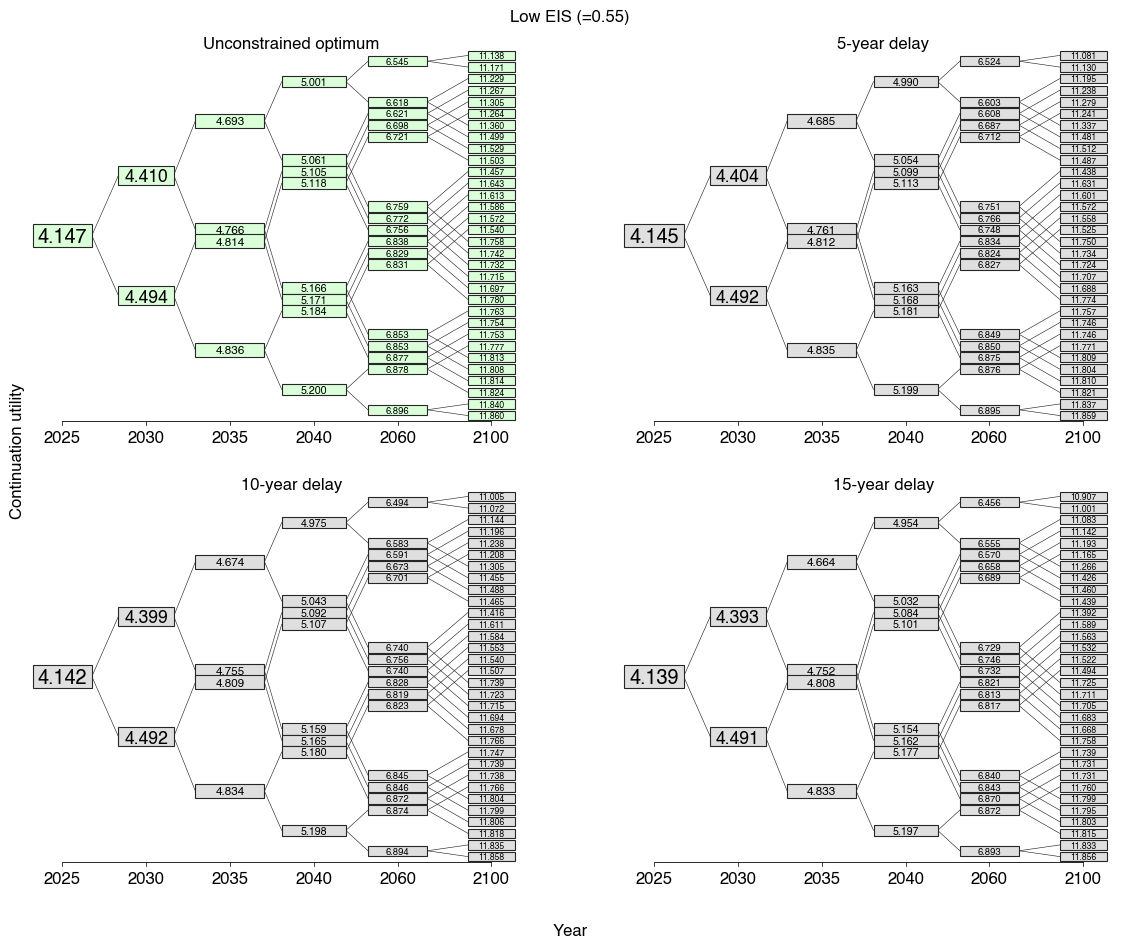

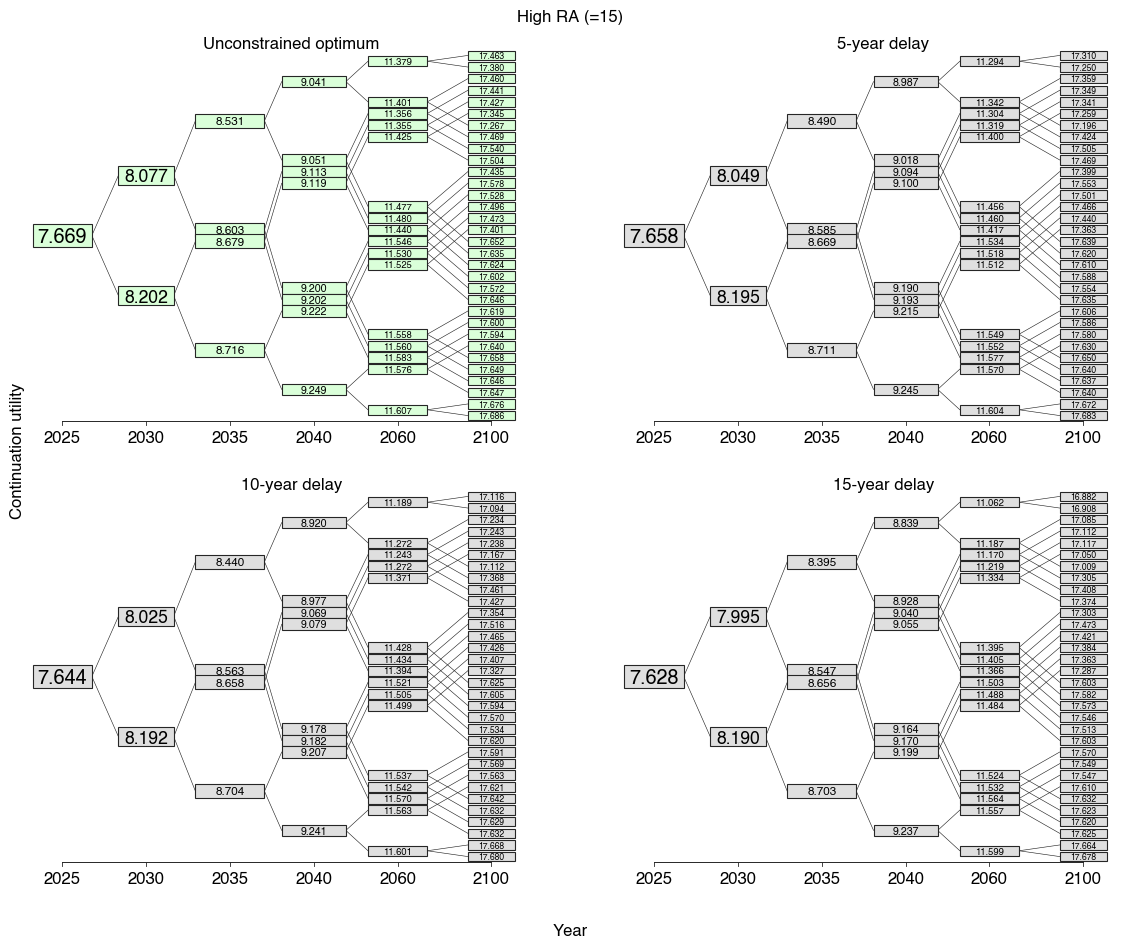

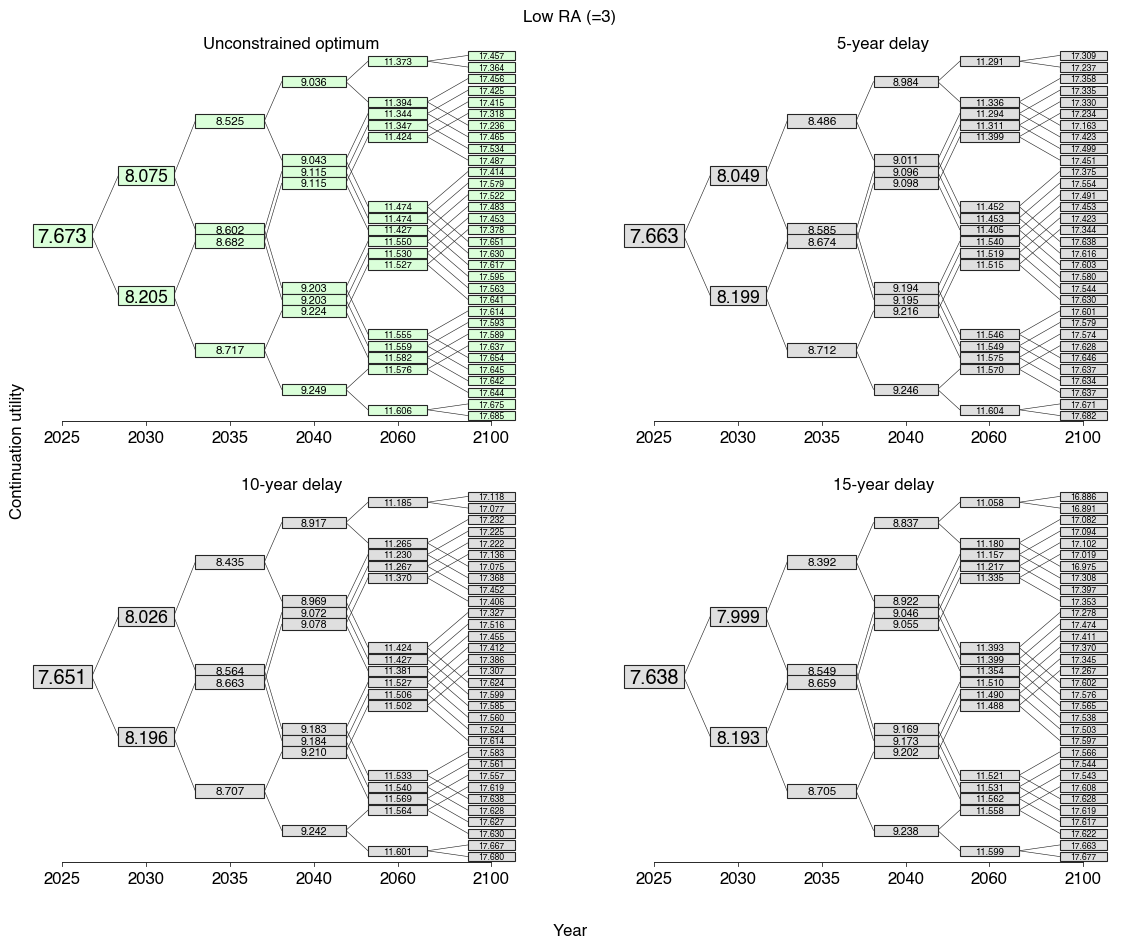

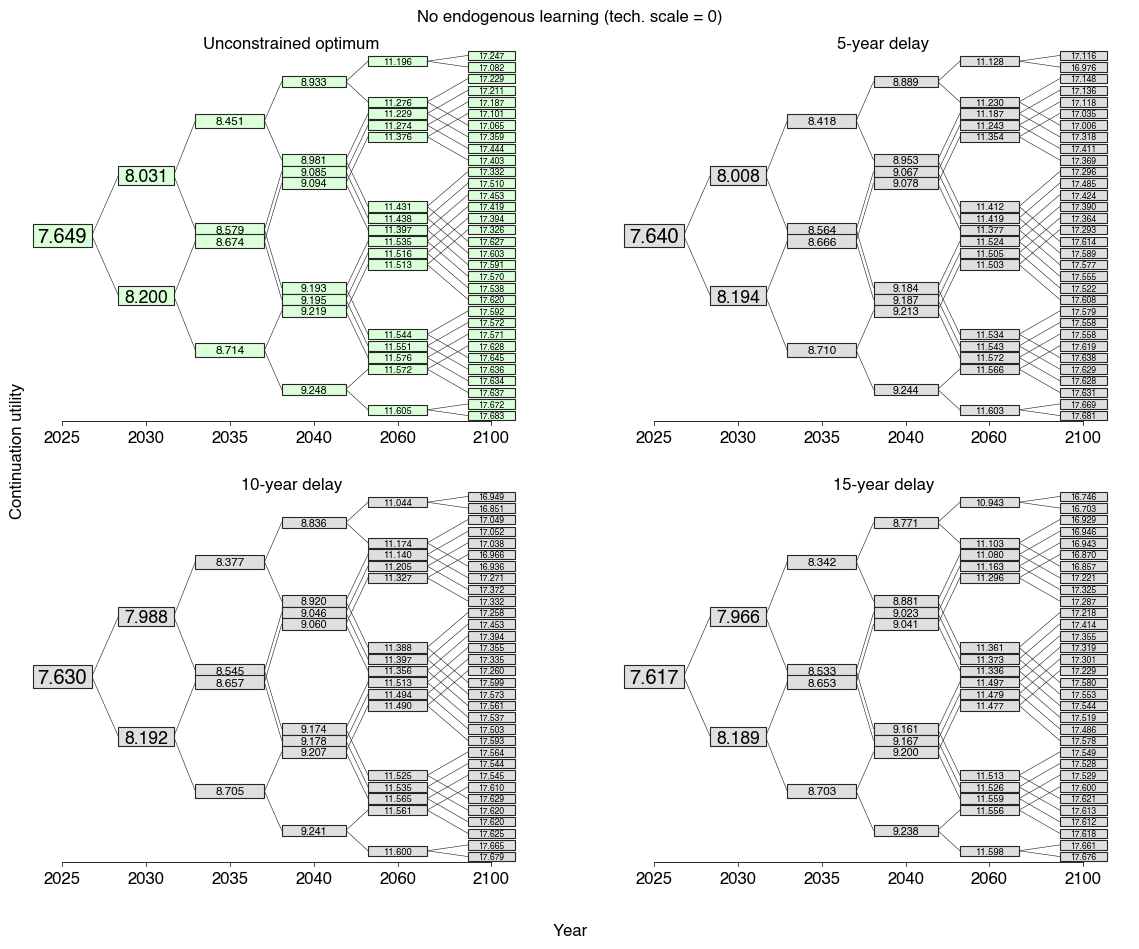

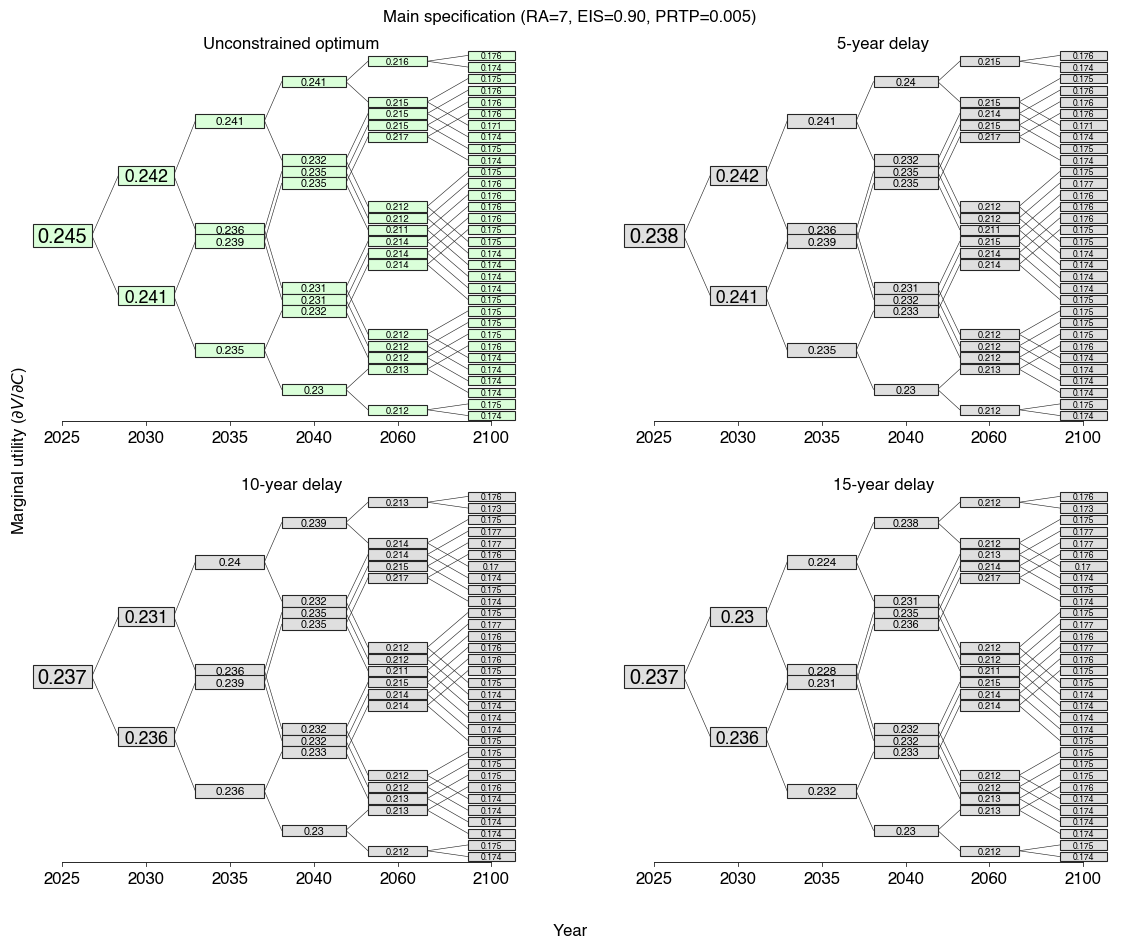

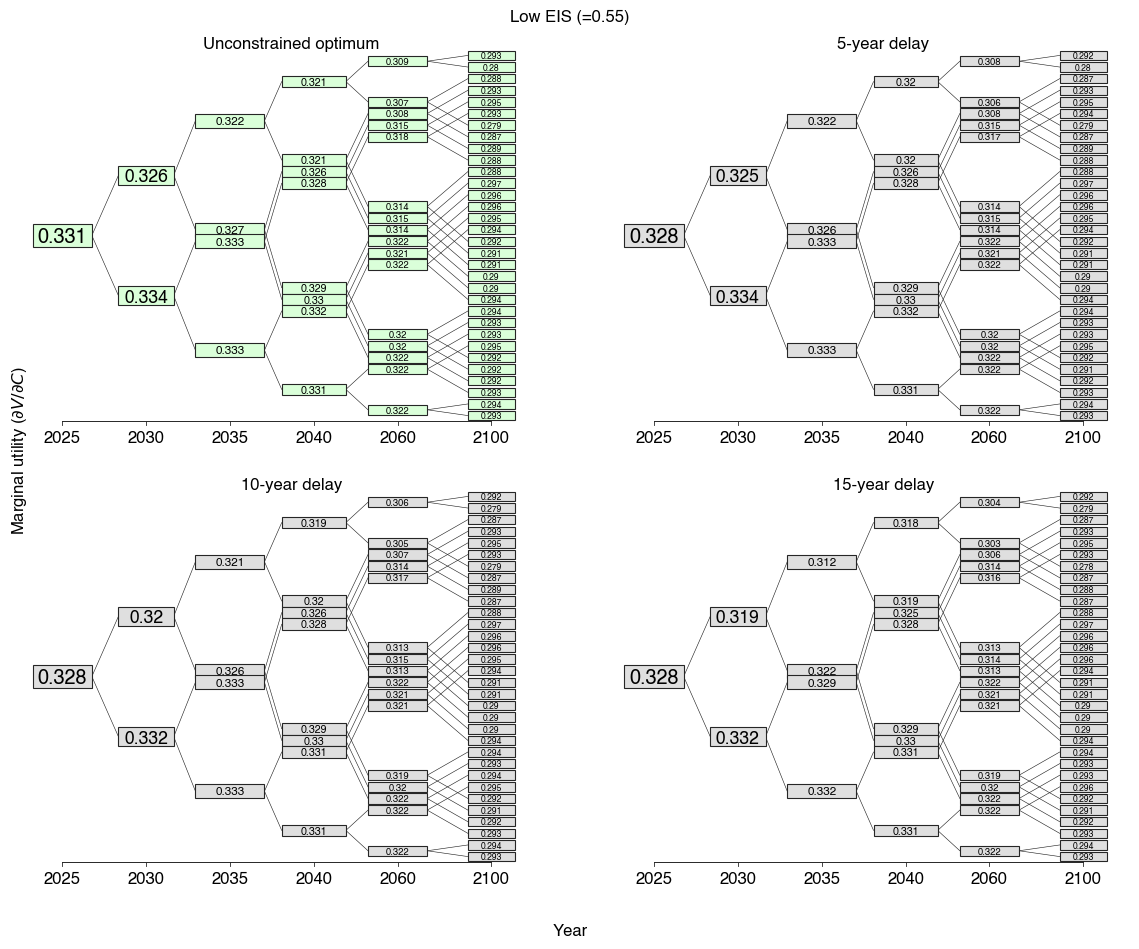

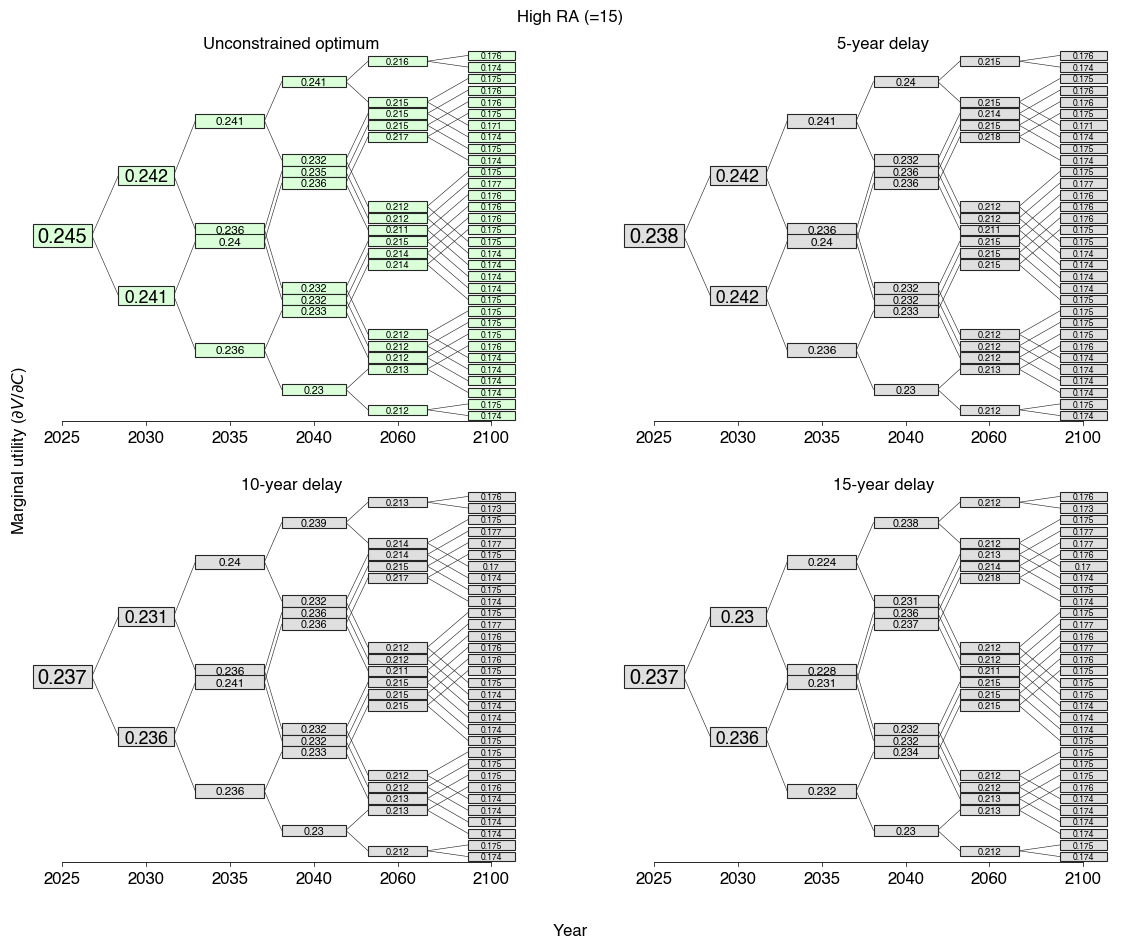

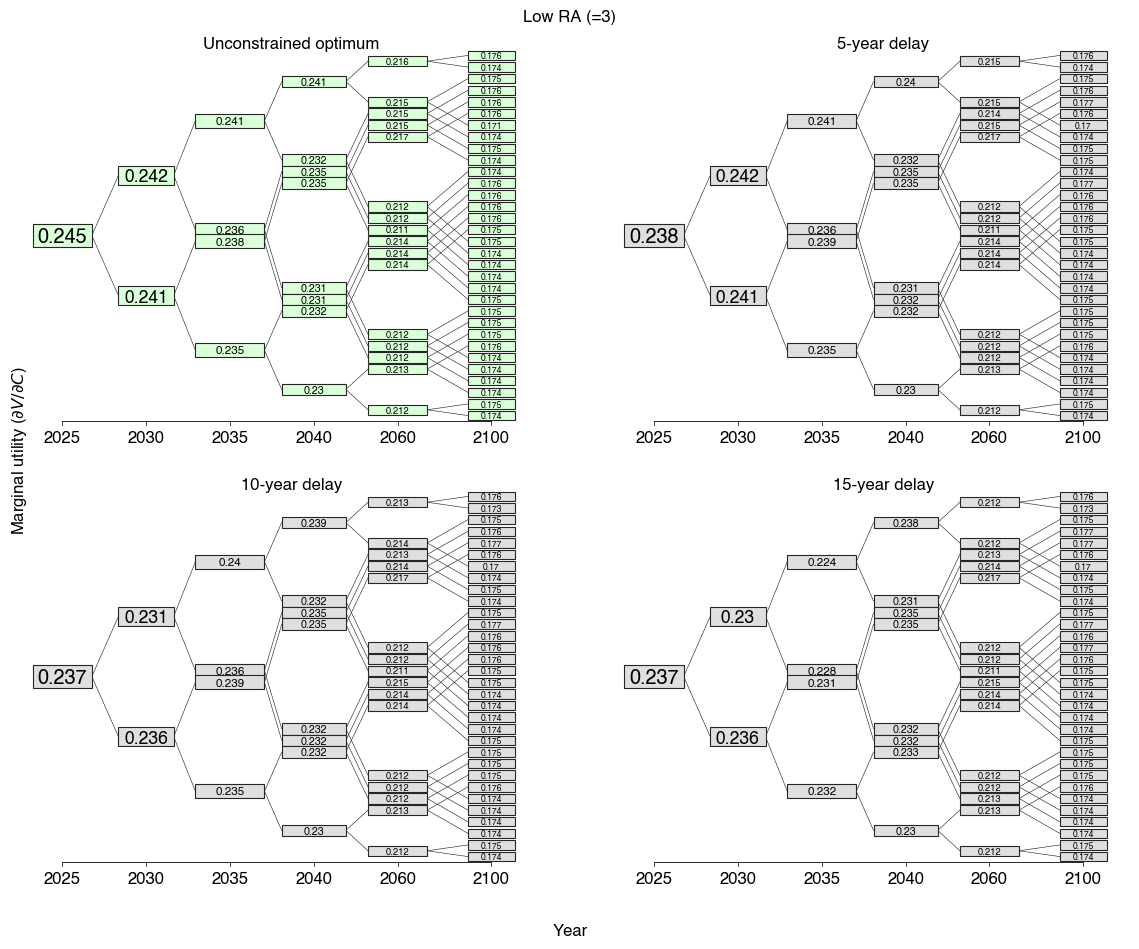

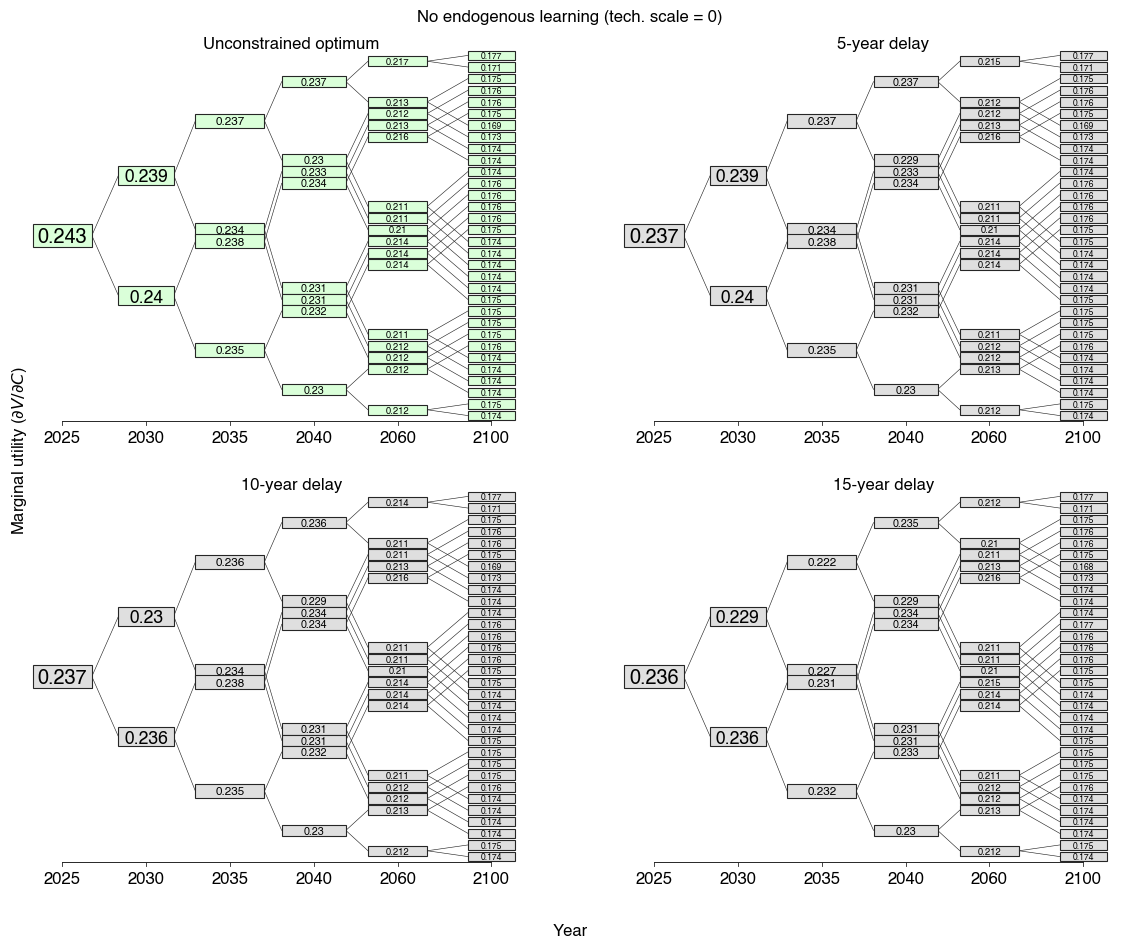

In [2]:
node_data = {run_key: read_nodes(run_key) for run_key in RUNS}
save_tree_figures(node_data)

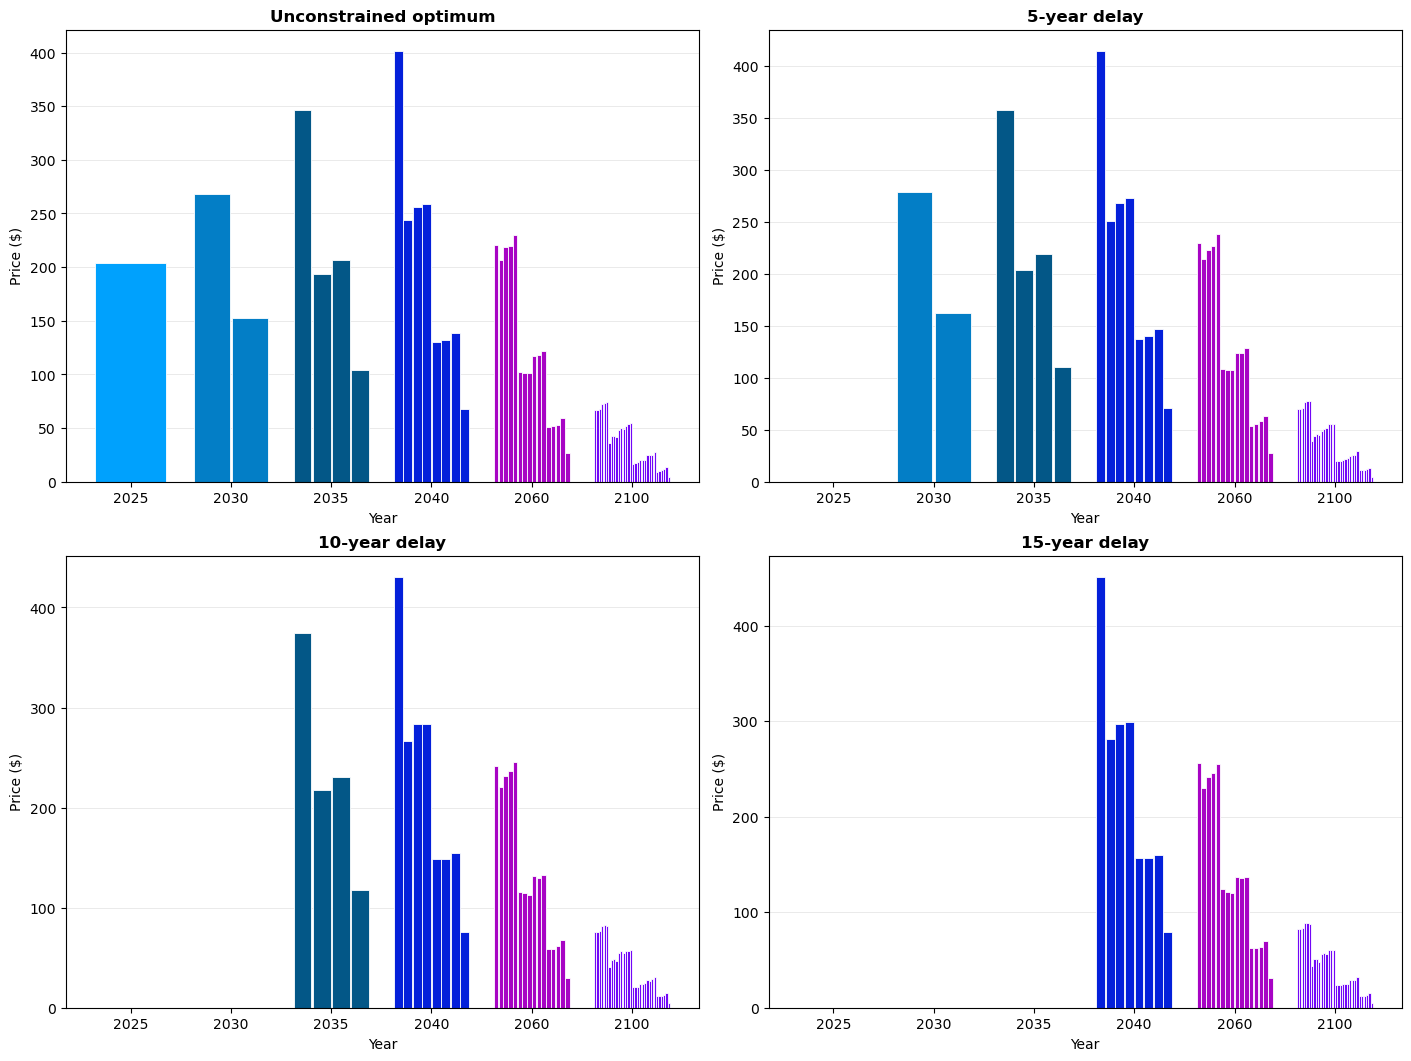

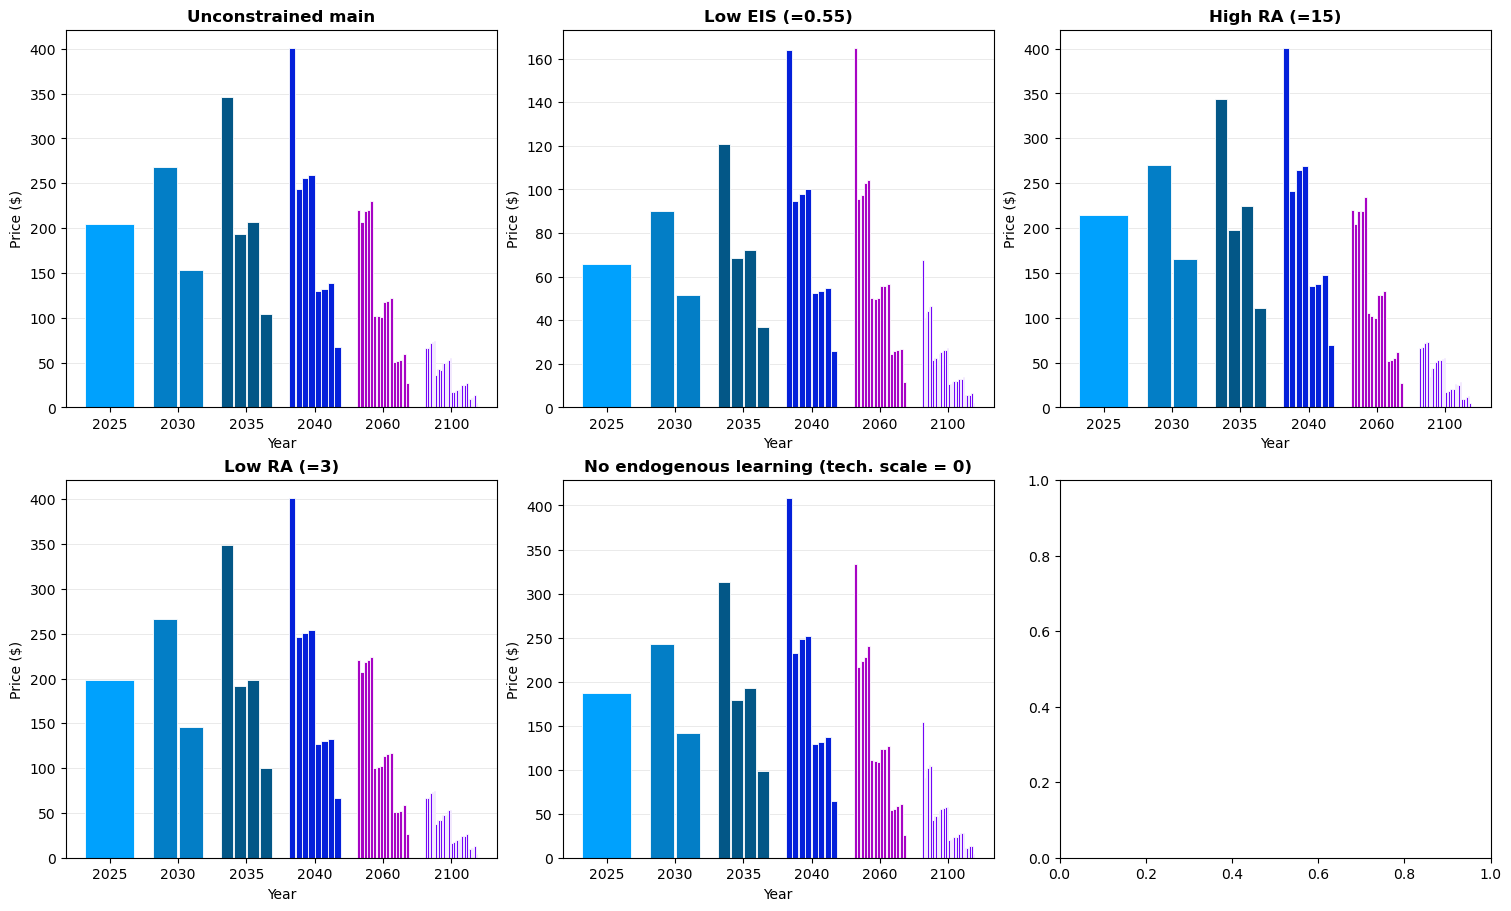

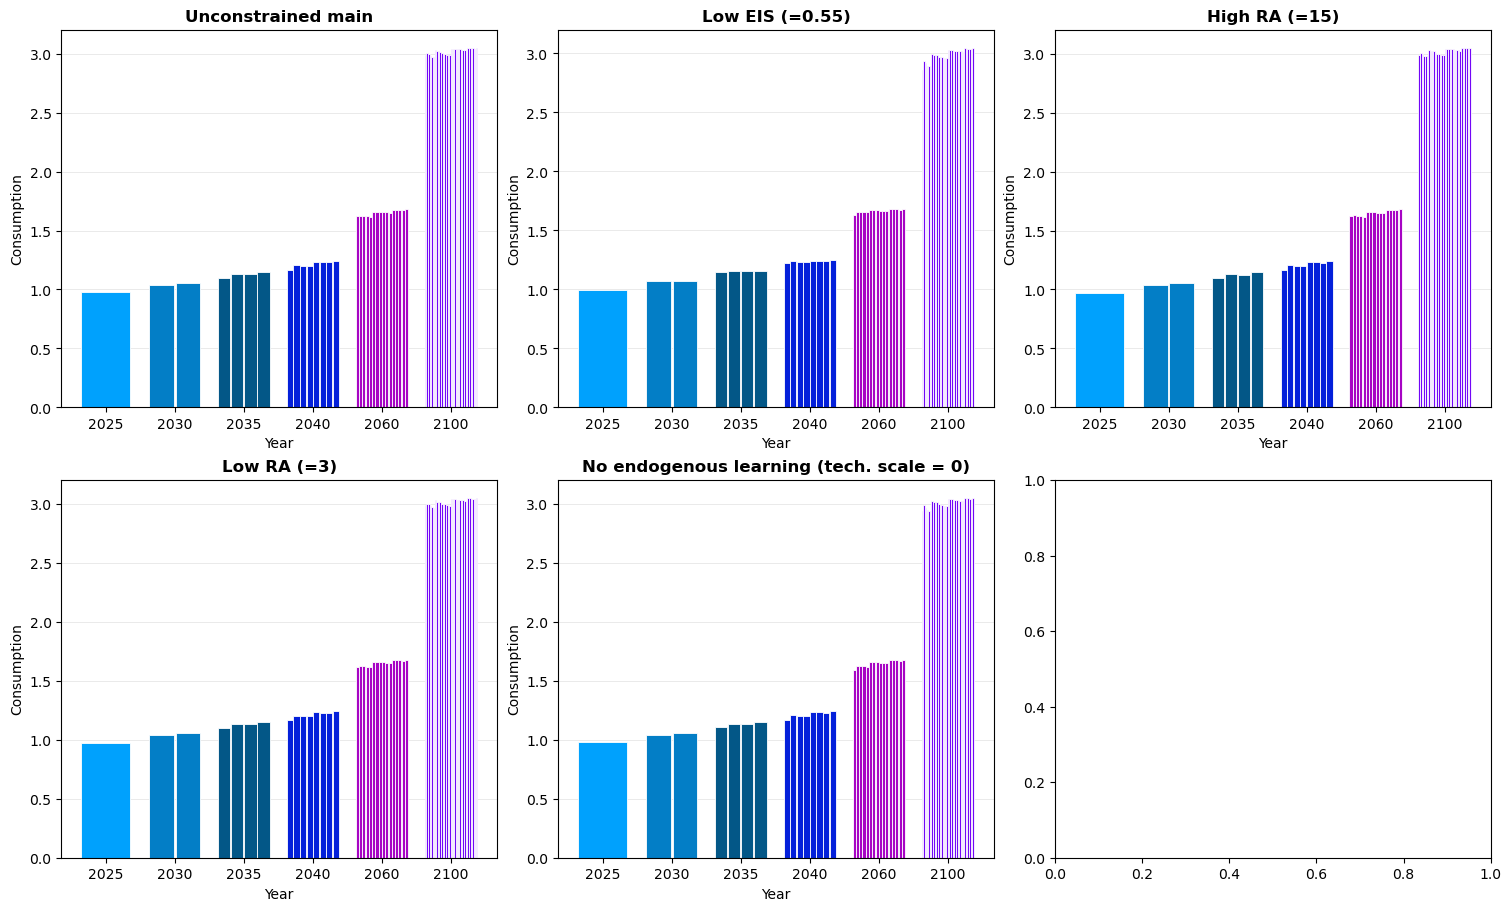

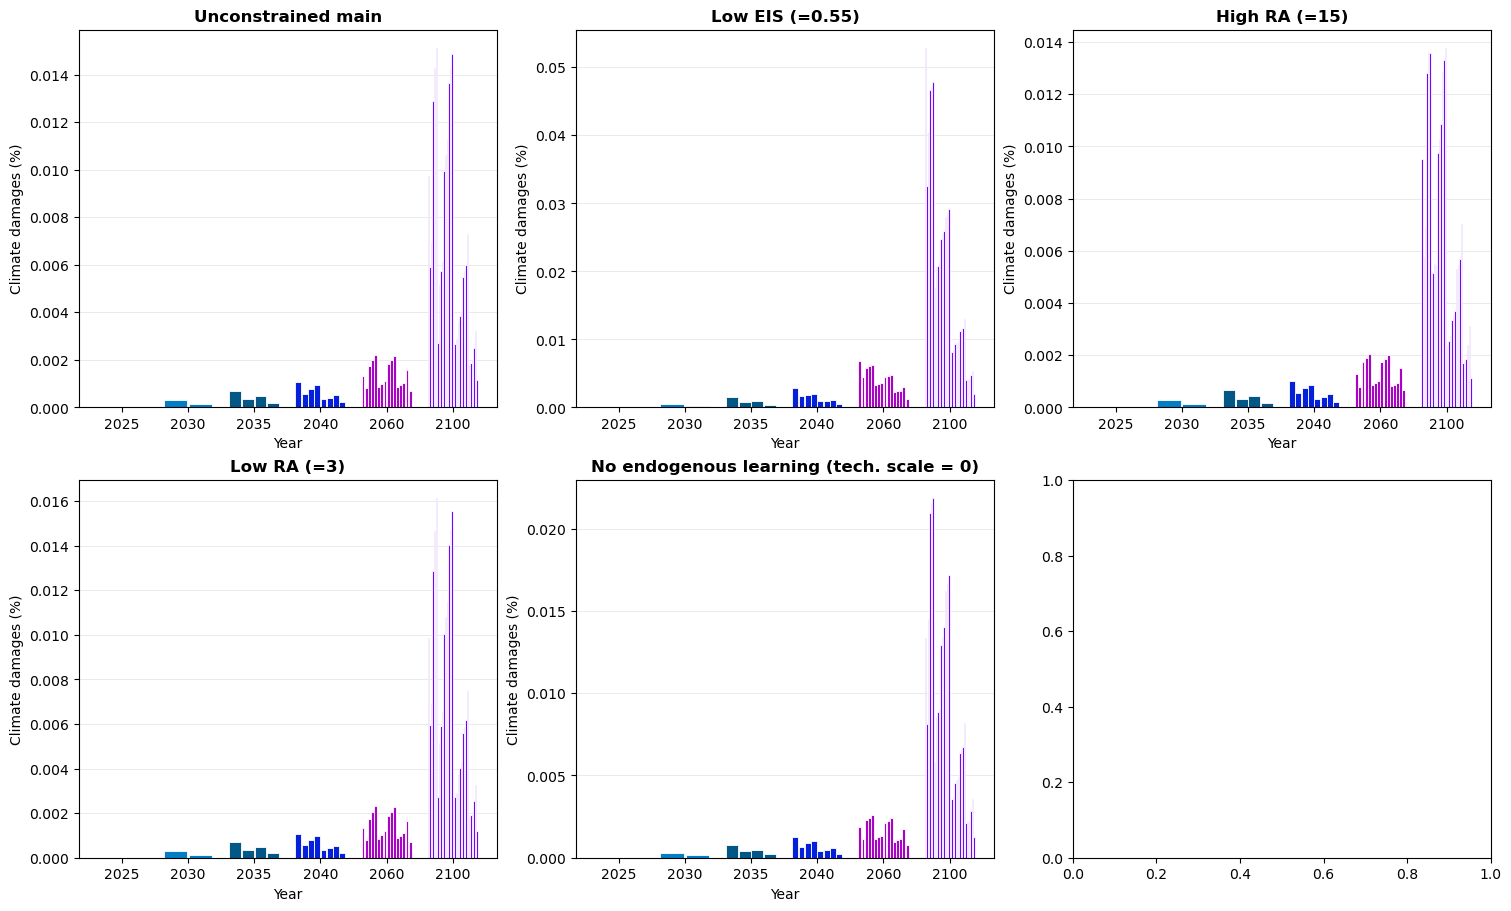

In [3]:
# Grouped bar-chart generation (run after the tree cell).
save_main_price_bar_figure(node_data)
save_unconstrained_comparison_bar_figures(node_data)